# Deep Learning Lab Practical 5
## RNN Architectures for Handwritten Character Recognition (MNIST & EMNIST)
### SVNIT Surat — Department of Artificial Intelligence — AI302

**Platform:** Kaggle Notebooks — T4 x2 GPU  
**Framework:** PyTorch

---
### Table of Contents
1. Setup & Imports
2. Dataset Loading & Visualization
3. **PS1**: Vanilla RNN (scratch + PyTorch, gradient analysis, row vs column scan)
4. **PS2**: LSTM (single/multi-layer, gate viz, dropout)
5. **PS3**: GRU (comparison with LSTM, efficiency analysis)
6. **PS4**: Bidirectional LSTM & BiGRU
7. **PS5**: CNN+LSTM Hybrid Architectures
8. **PS6**: Hyperparameter Tuning & Regularization
9. **PS7**: Comprehensive Comparative Analysis

---
## Section 0: Setup & Imports

In [1]:
# Install any missing libraries (Kaggle has most pre-installed)
!pip install -q torchinfo

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import time
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from collections import defaultdict

# Device setup — uses both T4 GPUs if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU count: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

torch.manual_seed(42)
np.random.seed(42)

Device: cuda
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


---
## Section 1: Dataset Loading & Visualization

In [3]:
# ─── Transforms ───────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

DATA_DIR = '/kaggle/working/data'

# ─── MNIST ────────────────────────────────────────────────────────────────────
mnist_train = torchvision.datasets.MNIST(root=DATA_DIR, train=True,  download=True, transform=transform)
mnist_test  = torchvision.datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

# ─── EMNIST Letters ───────────────────────────────────────────────────────────
emnist_letters_train = torchvision.datasets.EMNIST(root=DATA_DIR, split='letters', train=True,  download=True, transform=transform)
emnist_letters_test  = torchvision.datasets.EMNIST(root=DATA_DIR, split='letters', train=False, download=True, transform=transform)

# ─── EMNIST Balanced ──────────────────────────────────────────────────────────
emnist_bal_train = torchvision.datasets.EMNIST(root=DATA_DIR, split='balanced', train=True,  download=True, transform=transform)
emnist_bal_test  = torchvision.datasets.EMNIST(root=DATA_DIR, split='balanced', train=False, download=True, transform=transform)

# ─── EMNIST ByClass ───────────────────────────────────────────────────────────
emnist_byclass_train = torchvision.datasets.EMNIST(root=DATA_DIR, split='byclass', train=True,  download=True, transform=transform)
emnist_byclass_test  = torchvision.datasets.EMNIST(root=DATA_DIR, split='byclass', train=False, download=True, transform=transform)

print('MNIST         :', len(mnist_train), 'train,', len(mnist_test), 'test | classes:', mnist_train.classes[:5], '...')
print('EMNIST-Letters:', len(emnist_letters_train), 'train,', len(emnist_letters_test), 'test | classes:', len(emnist_letters_train.classes))
print('EMNIST-Balanced:', len(emnist_bal_train), 'train,', len(emnist_bal_test), 'test | classes:', len(emnist_bal_train.classes))
print('EMNIST-ByClass :', len(emnist_byclass_train), 'train,', len(emnist_byclass_test), 'test | classes:', len(emnist_byclass_train.classes))

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]
100%|██████████| 562M/562M [00:02<00:00, 251MB/s] 


MNIST         : 60000 train, 10000 test | classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four'] ...
EMNIST-Letters: 124800 train, 20800 test | classes: 27
EMNIST-Balanced: 112800 train, 18800 test | classes: 47
EMNIST-ByClass : 697932 train, 116323 test | classes: 62


In [4]:
# ─── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 128

mnist_loader_train = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
mnist_loader_test  = DataLoader(mnist_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

emnist_letters_train_loader = DataLoader(emnist_letters_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
emnist_letters_test_loader  = DataLoader(emnist_letters_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

emnist_bal_train_loader = DataLoader(emnist_bal_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
emnist_bal_test_loader  = DataLoader(emnist_bal_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# DataParallel helper — wraps model for multi-GPU if available
def to_device(model):
    model = model.to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    return model

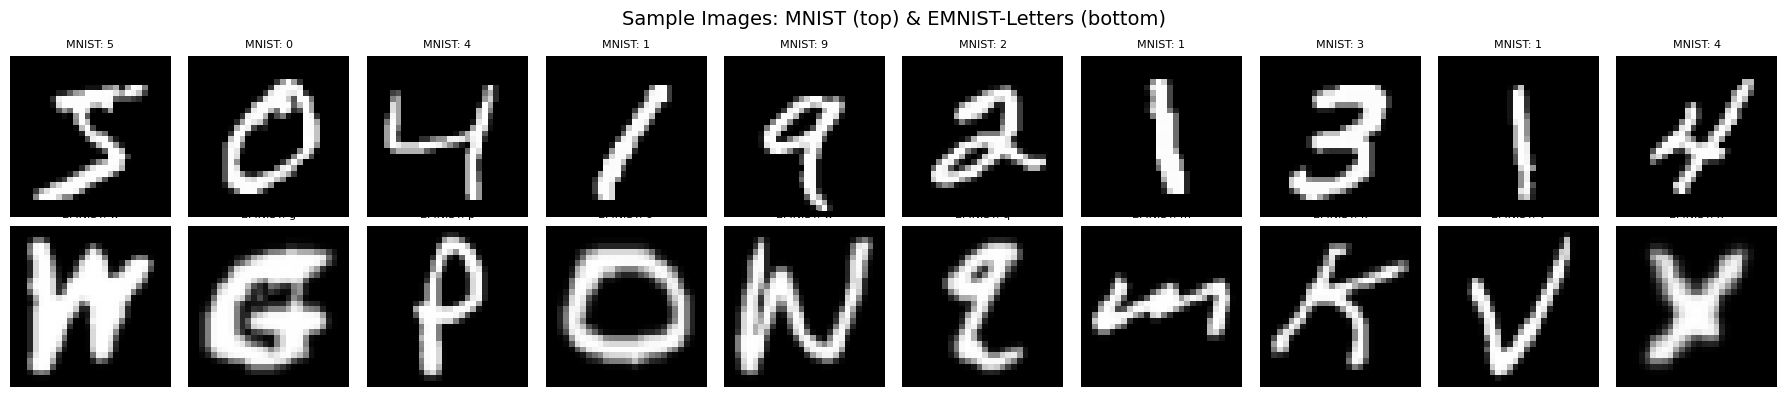

Key insight: 28×28 image → 28 time-steps, each with 28 features (row-by-row sequential processing)


In [5]:
# ─── Dataset Visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Sample Images: MNIST (top) & EMNIST-Letters (bottom)', fontsize=14)
for i in range(10):
    axes[0, i].imshow(mnist_train[i][0].squeeze(), cmap='gray')
    axes[0, i].set_title(f'MNIST: {mnist_train[i][1]}', fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(emnist_letters_train[i][0].squeeze().T, cmap='gray')  # EMNIST needs transpose
    axes[1, i].set_title(f'EMNIST: {emnist_letters_train.classes[emnist_letters_train[i][1]]}', fontsize=8)
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/dataset_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Key insight: 28×28 image → 28 time-steps, each with 28 features (row-by-row sequential processing)')

---
## Section 2 — Helper: Training Loop & Metrics

In [6]:
# ─── Universal Training Engine ─────────────────────────────────────────────────
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001,
                optimizer_name='adam', clip_grad=None, scheduler_type=None,
                track_gradients=False, label='model'):
    """
    General-purpose training loop.
    Returns: history dict with train_loss, train_acc, val_loss, val_acc,
             epoch_time, and optionally gradient_norms.
    """
    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_type == 'step':
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    else:
        scheduler = None

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}
    if track_gradients:
        history['grad_norms'] = []

    best_val_acc = 0.0
    best_weights = None
    patience_counter = 0
    PATIENCE = 5  # early stopping

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        epoch_grad_norms = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Shape: (B, 1, 28, 28) → (B, 28, 28) for RNNs
            inputs = inputs.squeeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            if clip_grad is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            if track_gradients:
                total_norm = 0.0
                for p in model.parameters():
                    if p.grad is not None:
                        total_norm += p.grad.data.norm(2).item() ** 2
                epoch_grad_norms.append(total_norm ** 0.5)

            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                inputs = inputs.squeeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss /= val_total
        val_acc   = 100.0 * val_correct / val_total
        epoch_time = time.time() - t0

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)
        if track_gradients:
            history['grad_norms'].append(np.mean(epoch_grad_norms))

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if scheduler:
            scheduler.step()

        print(f'[{label}] Epoch {epoch+1:02d}/{epochs} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | '
              f'Time: {epoch_time:.1f}s')

        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    if best_weights is not None:
        model.load_state_dict(best_weights)

    return history


def plot_history(histories, title='Training Curves'):
    """Plot loss & accuracy curves for one or more models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for label, h in histories.items():
        axes[0].plot(h['train_loss'], label=f'{label} Train')
        axes[0].plot(h['val_loss'],   label=f'{label} Val', linestyle='--')
        axes[1].plot(h['train_acc'],  label=f'{label} Train')
        axes[1].plot(h['val_acc'],    label=f'{label} Val', linestyle='--')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{title.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_inference_time(model, loader, n_batches=20):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (inputs, _) in enumerate(loader):
            if i >= n_batches: break
            inputs = inputs.squeeze(1).to(device)
            t0 = time.time()
            _ = model(inputs)
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            times.append(time.time() - t0)
    return np.mean(times) * 1000  # ms


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_features = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.squeeze(1).to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def plot_confusion_matrix(preds, labels, class_names, title='Confusion Matrix', max_classes=20):
    if len(class_names) > max_classes:
        class_names = class_names[:max_classes]
        mask = (preds < max_classes) & (labels < max_classes)
        preds, labels = preds[mask], labels[mask]
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)//2), max(6, len(class_names)//2)))
    sns.heatmap(cm, annot=len(class_names)<=15, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{title.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()


print('Helper functions ready!')

Helper functions ready!


---
## Problem Statement 1 — Vanilla RNN
### Task (a): Vanilla RNN from Scratch

In [7]:
# ─── Vanilla RNN from Scratch ──────────────────────────────────────────────────
class VanillaRNNCell(nn.Module):
    """Single RNN cell: h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b)"""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_ih = nn.Linear(input_size,  hidden_size, bias=True)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x, h):
        return torch.tanh(self.W_ih(x) + self.W_hh(h))


class VanillaRNNScratch(nn.Module):
    """Stacked Vanilla RNN built from scratch (no nn.RNN)."""
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        # Build list of RNN cells
        sizes = [input_size] + [hidden_size] * num_layers
        self.cells = nn.ModuleList([
            VanillaRNNCell(sizes[i], hidden_size) for i in range(num_layers)
        ])
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, T, 28)
        B, T, _ = x.size()
        h = [torch.zeros(B, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
        for t in range(T):
            inp = x[:, t, :]    # (B, input_size)
            for l, cell in enumerate(self.cells):
                h[l] = cell(inp, h[l])
                inp = h[l]
        return self.fc(h[-1])   # Use last hidden state


# ─── Vanilla RNN using nn.RNN ──────────────────────────────────────────────────
class VanillaRNNPyTorch(nn.Module):
    """Vanilla RNN using torch.nn.RNN."""
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.0):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)   # out: (B, T, H)
        return self.fc(out[:, -1, :])   # last time-step

print('Vanilla RNN models defined.')

Vanilla RNN models defined.


RNN Scratch params: 21,386
RNN PyTorch params: 21,514

--- Training RNN from Scratch ---
[RNN-Scratch] Epoch 01/10 | Train Loss: 0.8807 Acc: 70.61% | Val Loss: 0.4612 Acc: 86.05% | Time: 16.7s
[RNN-Scratch] Epoch 02/10 | Train Loss: 0.3343 Acc: 90.49% | Val Loss: 0.2540 Acc: 92.79% | Time: 15.0s
[RNN-Scratch] Epoch 03/10 | Train Loss: 0.2298 Acc: 93.59% | Val Loss: 0.2176 Acc: 93.96% | Time: 15.0s
[RNN-Scratch] Epoch 04/10 | Train Loss: 0.1915 Acc: 94.61% | Val Loss: 0.1852 Acc: 95.01% | Time: 14.7s
[RNN-Scratch] Epoch 05/10 | Train Loss: 0.1661 Acc: 95.36% | Val Loss: 0.1542 Acc: 95.61% | Time: 14.8s
[RNN-Scratch] Epoch 06/10 | Train Loss: 0.1524 Acc: 95.71% | Val Loss: 0.1487 Acc: 95.87% | Time: 15.2s
[RNN-Scratch] Epoch 07/10 | Train Loss: 0.1372 Acc: 96.14% | Val Loss: 0.1534 Acc: 95.78% | Time: 15.0s
[RNN-Scratch] Epoch 08/10 | Train Loss: 0.1316 Acc: 96.24% | Val Loss: 0.1258 Acc: 96.72% | Time: 14.9s
[RNN-Scratch] Epoch 09/10 | Train Loss: 0.1189 Acc: 96.63% | Val Loss: 0.1345 A

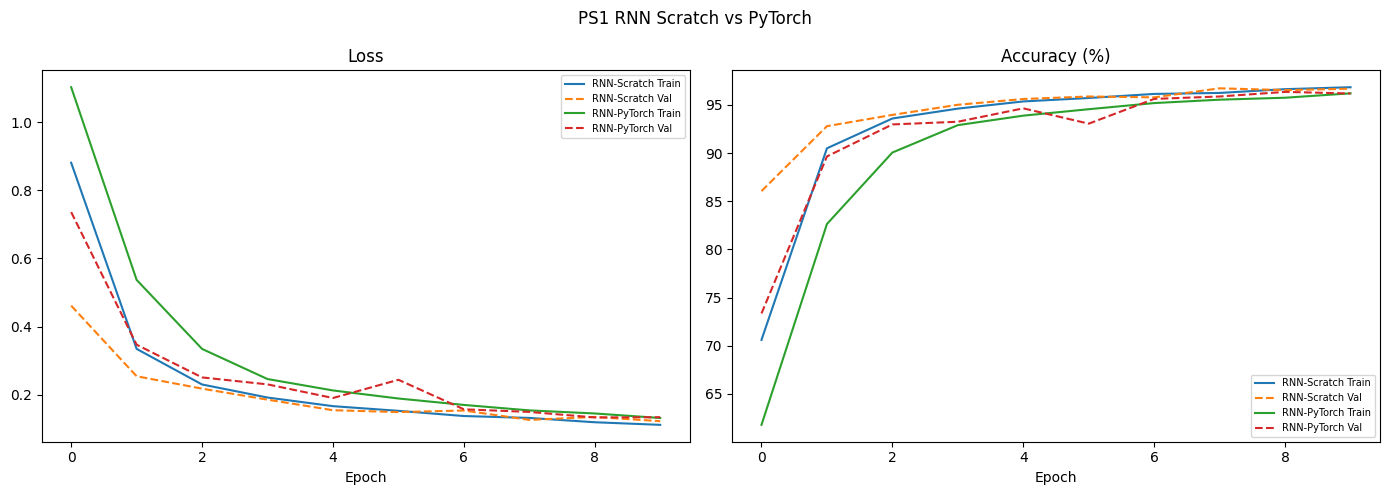

In [8]:
# ─── PS1 Task (a): Train RNN from Scratch vs PyTorch on MNIST ─────────────────
rnn_scratch = to_device(VanillaRNNScratch(hidden_size=128, num_layers=1, num_classes=10))
rnn_pytorch = to_device(VanillaRNNPyTorch(hidden_size=128, num_layers=1, num_classes=10))

print(f'RNN Scratch params: {count_parameters(rnn_scratch):,}')
print(f'RNN PyTorch params: {count_parameters(rnn_pytorch):,}')

EPOCHS_PS1 = 10
print('\n--- Training RNN from Scratch ---')
h_rnn_scratch = train_model(rnn_scratch, mnist_loader_train, mnist_loader_test,
                            epochs=EPOCHS_PS1, label='RNN-Scratch', track_gradients=True)

print('\n--- Training RNN PyTorch ---')
h_rnn_pytorch = train_model(rnn_pytorch, mnist_loader_train, mnist_loader_test,
                            epochs=EPOCHS_PS1, label='RNN-PyTorch', track_gradients=True)

plot_history({'RNN-Scratch': h_rnn_scratch, 'RNN-PyTorch': h_rnn_pytorch},
             title='PS1 RNN Scratch vs PyTorch')

=== PS1(b): Vanishing Gradient Analysis ===
[RNN-1L] Epoch 01/5 | Train Loss: 0.9295 Acc: 67.85% | Val Loss: 0.5660 Acc: 81.39% | Time: 8.2s
[RNN-1L] Epoch 02/5 | Train Loss: 0.4178 Acc: 87.26% | Val Loss: 0.2999 Acc: 91.43% | Time: 8.2s
[RNN-1L] Epoch 03/5 | Train Loss: 0.2934 Acc: 91.62% | Val Loss: 0.2609 Acc: 92.74% | Time: 8.1s
[RNN-1L] Epoch 04/5 | Train Loss: 0.2306 Acc: 93.42% | Val Loss: 0.2287 Acc: 93.47% | Time: 8.3s
[RNN-1L] Epoch 05/5 | Train Loss: 0.1922 Acc: 94.47% | Val Loss: 0.1682 Acc: 95.32% | Time: 8.2s
[RNN-2L] Epoch 01/5 | Train Loss: 0.7507 Acc: 74.58% | Val Loss: 0.3534 Acc: 89.37% | Time: 8.6s
[RNN-2L] Epoch 02/5 | Train Loss: 0.2967 Acc: 91.31% | Val Loss: 0.2085 Acc: 94.20% | Time: 8.6s
[RNN-2L] Epoch 03/5 | Train Loss: 0.2067 Acc: 93.99% | Val Loss: 0.1953 Acc: 94.51% | Time: 8.5s
[RNN-2L] Epoch 04/5 | Train Loss: 0.1693 Acc: 95.19% | Val Loss: 0.1515 Acc: 95.69% | Time: 8.5s
[RNN-2L] Epoch 05/5 | Train Loss: 0.1500 Acc: 95.65% | Val Loss: 0.1172 Acc: 96.62%

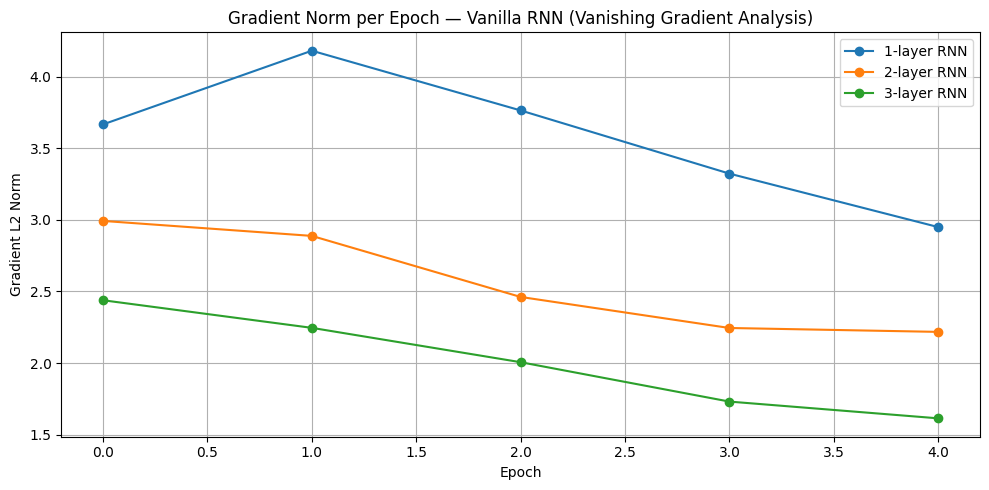

Observation: Deeper vanilla RNNs show smaller gradient norms (vanishing gradient problem).


In [9]:
# ─── PS1 Task (b): Vanishing Gradient Analysis ────────────────────────────────
print('=== PS1(b): Vanishing Gradient Analysis ===')

layer_configs = [1, 2, 3]
grad_histories = {}

for n_layers in layer_configs:
    m = to_device(VanillaRNNPyTorch(hidden_size=128, num_layers=n_layers, num_classes=10))
    h = train_model(m, mnist_loader_train, mnist_loader_test,
                    epochs=5, label=f'RNN-{n_layers}L', track_gradients=True)
    grad_histories[f'{n_layers}-layer RNN'] = h

# Plot gradient norms
fig, ax = plt.subplots(figsize=(10, 5))
for label, h in grad_histories.items():
    if 'grad_norms' in h:
        ax.plot(h['grad_norms'], marker='o', label=label)
ax.set_title('Gradient Norm per Epoch — Vanilla RNN (Vanishing Gradient Analysis)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Gradient L2 Norm'); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/PS1b_gradient_norms.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observation: Deeper vanilla RNNs show smaller gradient norms (vanishing gradient problem).')

=== PS1(c): Row-wise vs Column-wise Scanning ===
Training Row-wise RNN...
[Row-RNN] Epoch 01/8 | Train Loss: 0.9129 Acc: 69.24% | Val Loss: 0.5488 Acc: 82.53% | Time: 8.1s
[Row-RNN] Epoch 02/8 | Train Loss: 0.4688 Acc: 86.05% | Val Loss: 0.3883 Acc: 88.87% | Time: 8.1s
[Row-RNN] Epoch 03/8 | Train Loss: 0.3328 Acc: 90.64% | Val Loss: 0.2633 Acc: 92.62% | Time: 8.2s
[Row-RNN] Epoch 04/8 | Train Loss: 0.2589 Acc: 92.81% | Val Loss: 0.2270 Acc: 93.77% | Time: 8.2s
[Row-RNN] Epoch 05/8 | Train Loss: 0.2153 Acc: 94.01% | Val Loss: 0.1900 Acc: 94.74% | Time: 8.2s
[Row-RNN] Epoch 06/8 | Train Loss: 0.1860 Acc: 94.83% | Val Loss: 0.1783 Acc: 95.09% | Time: 8.2s
[Row-RNN] Epoch 07/8 | Train Loss: 0.1661 Acc: 95.33% | Val Loss: 0.1781 Acc: 95.05% | Time: 8.1s
[Row-RNN] Epoch 08/8 | Train Loss: 0.1501 Acc: 95.72% | Val Loss: 0.1345 Acc: 96.19% | Time: 8.1s
Training Column-wise RNN...
[Col-RNN] Epoch 01/8 | Train Loss: 1.1446 Acc: 58.83% | Val Loss: 0.5373 Acc: 83.72% | Time: 8.1s
[Col-RNN] Epoch 

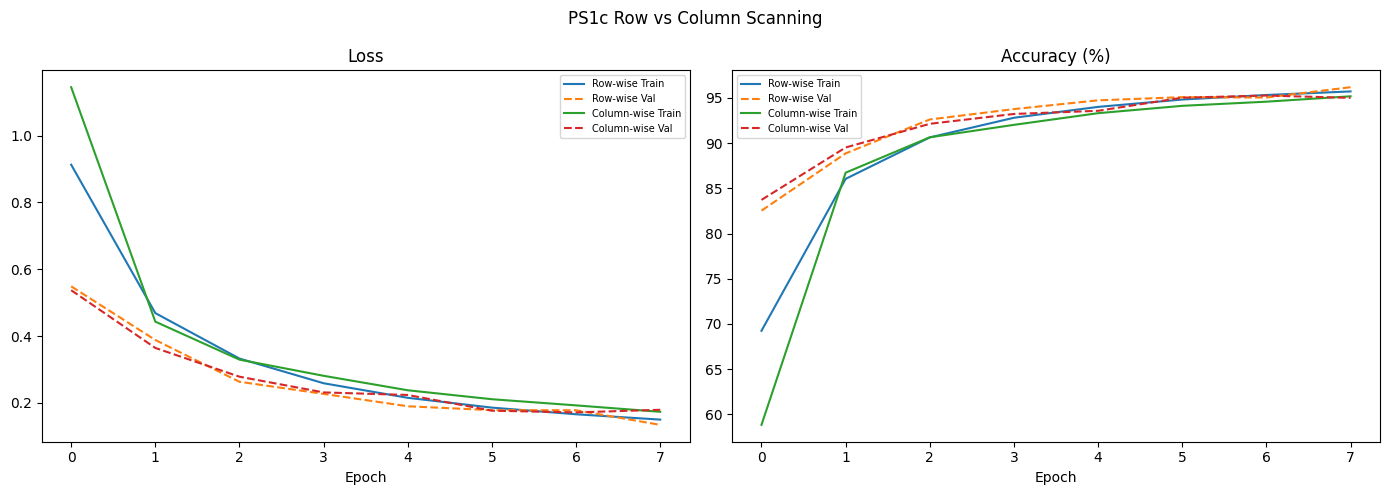

Best Row-wise accuracy : 96.19%
Best Column-wise accuracy: 95.27%


In [10]:
# ─── PS1 Task (c): Row-wise vs Column-wise Scanning ───────────────────────────
print('=== PS1(c): Row-wise vs Column-wise Scanning ===')

class ScanRNN(nn.Module):
    """RNN with configurable scan direction."""
    def __init__(self, hidden_size=128, num_classes=10, scan='row'):
        super().__init__()
        self.scan = scan
        self.rnn = nn.RNN(28, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, 28, 28)
        if self.scan == 'col':
            x = x.permute(0, 2, 1)  # Transpose → (B, 28, 28) column-wise
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

rnn_row = to_device(ScanRNN(scan='row'))
rnn_col = to_device(ScanRNN(scan='col'))

print('Training Row-wise RNN...')
h_row = train_model(rnn_row, mnist_loader_train, mnist_loader_test, epochs=8, label='Row-RNN')
print('Training Column-wise RNN...')
h_col = train_model(rnn_col, mnist_loader_train, mnist_loader_test, epochs=8, label='Col-RNN')

plot_history({'Row-wise': h_row, 'Column-wise': h_col}, title='PS1c Row vs Column Scanning')
print(f'Best Row-wise accuracy : {max(h_row["val_acc"]):.2f}%')
print(f'Best Column-wise accuracy: {max(h_col["val_acc"]):.2f}%')

In [11]:
# ─── PS1 Task (d): Hidden Units Comparison on MNIST ───────────────────────────
print('=== PS1(d): Hidden Units Comparison ===')

hidden_unit_results = {}
for hu in [64, 128, 256]:
    m = to_device(VanillaRNNPyTorch(hidden_size=hu, num_layers=2, num_classes=10))
    h = train_model(m, mnist_loader_train, mnist_loader_test,
                    epochs=8, label=f'RNN-H{hu}')
    hidden_unit_results[f'H={hu}'] = {
        'best_acc': max(h['val_acc']),
        'params': count_parameters(m),
        'avg_epoch_time': np.mean(h['epoch_time'])
    }

df_hu = pd.DataFrame(hidden_unit_results).T
print('\nHidden Units Comparison:')
print(df_hu.to_string())

=== PS1(d): Hidden Units Comparison ===
[RNN-H64] Epoch 01/8 | Train Loss: 1.0300 Acc: 64.78% | Val Loss: 0.6289 Acc: 78.81% | Time: 8.2s
[RNN-H64] Epoch 02/8 | Train Loss: 0.5176 Acc: 82.74% | Val Loss: 0.4633 Acc: 85.02% | Time: 8.2s
[RNN-H64] Epoch 03/8 | Train Loss: 0.3672 Acc: 88.89% | Val Loss: 0.2905 Acc: 91.39% | Time: 8.3s
[RNN-H64] Epoch 04/8 | Train Loss: 0.2712 Acc: 92.29% | Val Loss: 0.2272 Acc: 93.64% | Time: 8.3s
[RNN-H64] Epoch 05/8 | Train Loss: 0.2212 Acc: 93.77% | Val Loss: 0.2025 Acc: 94.18% | Time: 8.3s
[RNN-H64] Epoch 06/8 | Train Loss: 0.1902 Acc: 94.57% | Val Loss: 0.1584 Acc: 95.75% | Time: 8.3s
[RNN-H64] Epoch 07/8 | Train Loss: 0.1719 Acc: 95.17% | Val Loss: 0.1599 Acc: 95.63% | Time: 8.3s
[RNN-H64] Epoch 08/8 | Train Loss: 0.1526 Acc: 95.67% | Val Loss: 0.1541 Acc: 95.93% | Time: 8.2s
[RNN-H128] Epoch 01/8 | Train Loss: 0.7329 Acc: 75.09% | Val Loss: 0.3229 Acc: 90.68% | Time: 8.3s
[RNN-H128] Epoch 02/8 | Train Loss: 0.2865 Acc: 91.94% | Val Loss: 0.2230 Acc

---
## Problem Statement 2 — LSTM

In [12]:
# ─── LSTM Model ───────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    """
    Stacked LSTM with optional dropout.
    Also exposes gate activations via a hook for visualization.
    """
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
        # For gate visualization
        self._gate_values = None

    def forward(self, x, return_gates=False):
        out, (h, c) = self.lstm(x)
        last = self.dropout(out[:, -1, :])
        return self.fc(last)

    def get_gates(self, x):
        """Manually compute gate values for visualization (single-layer only)."""
        with torch.no_grad():
            B, T, _ = x.size()
            h = torch.zeros(B, self.hidden_size).to(x.device)
            c = torch.zeros(B, self.hidden_size).to(x.device)
            W = self.lstm.weight_ih_l0  # (4H, input_size)
            U = self.lstm.weight_hh_l0  # (4H, H)
            b = self.lstm.bias_ih_l0 + self.lstm.bias_hh_l0
            H = self.hidden_size
            gates_over_time = []
            for t in range(T):
                gates = x[:, t, :] @ W.T + h @ U.T + b
                i_gate = torch.sigmoid(gates[:, :H])
                f_gate = torch.sigmoid(gates[:, H:2*H])
                g_gate = torch.tanh(gates[:, 2*H:3*H])
                o_gate = torch.sigmoid(gates[:, 3*H:])
                c = f_gate * c + i_gate * g_gate
                h = o_gate * torch.tanh(c)
                gates_over_time.append({
                    'input':  i_gate.mean(0).cpu().numpy(),
                    'forget': f_gate.mean(0).cpu().numpy(),
                    'output': o_gate.mean(0).cpu().numpy(),
                    'cell':   g_gate.mean(0).cpu().numpy()
                })
        return gates_over_time

print('LSTM model defined.')

LSTM model defined.


=== PS2(e): Single vs Multi-layer LSTM ===
[LSTM-1L] Epoch 01/10 | Train Loss: 0.5347 Acc: 82.44% | Val Loss: 0.1573 Acc: 95.32% | Time: 8.3s
[LSTM-1L] Epoch 02/10 | Train Loss: 0.1358 Acc: 95.97% | Val Loss: 0.0986 Acc: 97.16% | Time: 8.4s
[LSTM-1L] Epoch 03/10 | Train Loss: 0.0939 Acc: 97.22% | Val Loss: 0.0825 Acc: 97.63% | Time: 8.5s
[LSTM-1L] Epoch 04/10 | Train Loss: 0.0736 Acc: 97.75% | Val Loss: 0.0648 Acc: 98.06% | Time: 8.3s
[LSTM-1L] Epoch 05/10 | Train Loss: 0.0599 Acc: 98.22% | Val Loss: 0.0618 Acc: 98.17% | Time: 8.3s
[LSTM-1L] Epoch 06/10 | Train Loss: 0.0487 Acc: 98.55% | Val Loss: 0.0572 Acc: 98.37% | Time: 8.3s
[LSTM-1L] Epoch 07/10 | Train Loss: 0.0440 Acc: 98.64% | Val Loss: 0.0515 Acc: 98.41% | Time: 8.3s
[LSTM-1L] Epoch 08/10 | Train Loss: 0.0381 Acc: 98.87% | Val Loss: 0.0553 Acc: 98.32% | Time: 8.2s
[LSTM-1L] Epoch 09/10 | Train Loss: 0.0338 Acc: 98.95% | Val Loss: 0.0766 Acc: 97.73% | Time: 8.3s
[LSTM-1L] Epoch 10/10 | Train Loss: 0.0329 Acc: 98.92% | Val Loss:

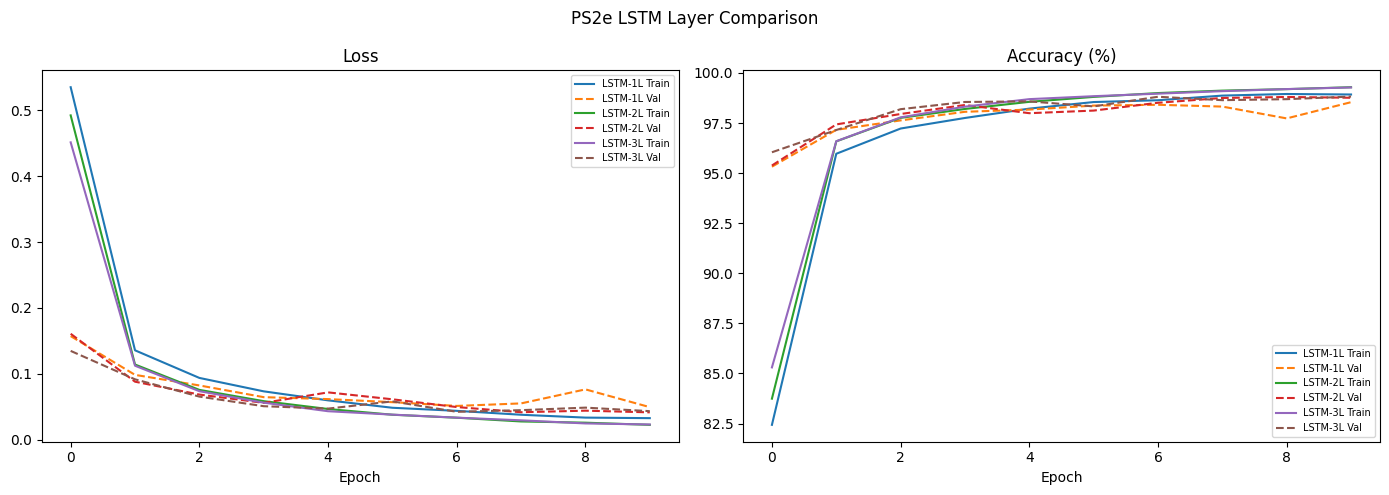

LSTM-1L: Best Val Acc = 98.54%  Params = 82,186
LSTM-2L: Best Val Acc = 98.80%  Params = 214,282
LSTM-3L: Best Val Acc = 98.82%  Params = 346,378


In [13]:
# ─── PS2 Task (e): Single vs Multi-layer LSTM ─────────────────────────────────
print('=== PS2(e): Single vs Multi-layer LSTM ===')

lstm_histories = {}
lstm_models    = {}

for n_layers in [1, 2, 3]:
    m = to_device(LSTMModel(hidden_size=128, num_layers=n_layers, num_classes=10))
    h = train_model(m, mnist_loader_train, mnist_loader_test,
                    epochs=10, label=f'LSTM-{n_layers}L')
    lstm_histories[f'LSTM-{n_layers}L'] = h
    lstm_models[f'LSTM-{n_layers}L']    = m

plot_history(lstm_histories, title='PS2e LSTM Layer Comparison')
for k in lstm_histories:
    print(f'{k}: Best Val Acc = {max(lstm_histories[k]["val_acc"]):.2f}%  Params = {count_parameters(lstm_models[k]):,}')

=== PS2(f): LSTM Gate Visualization ===


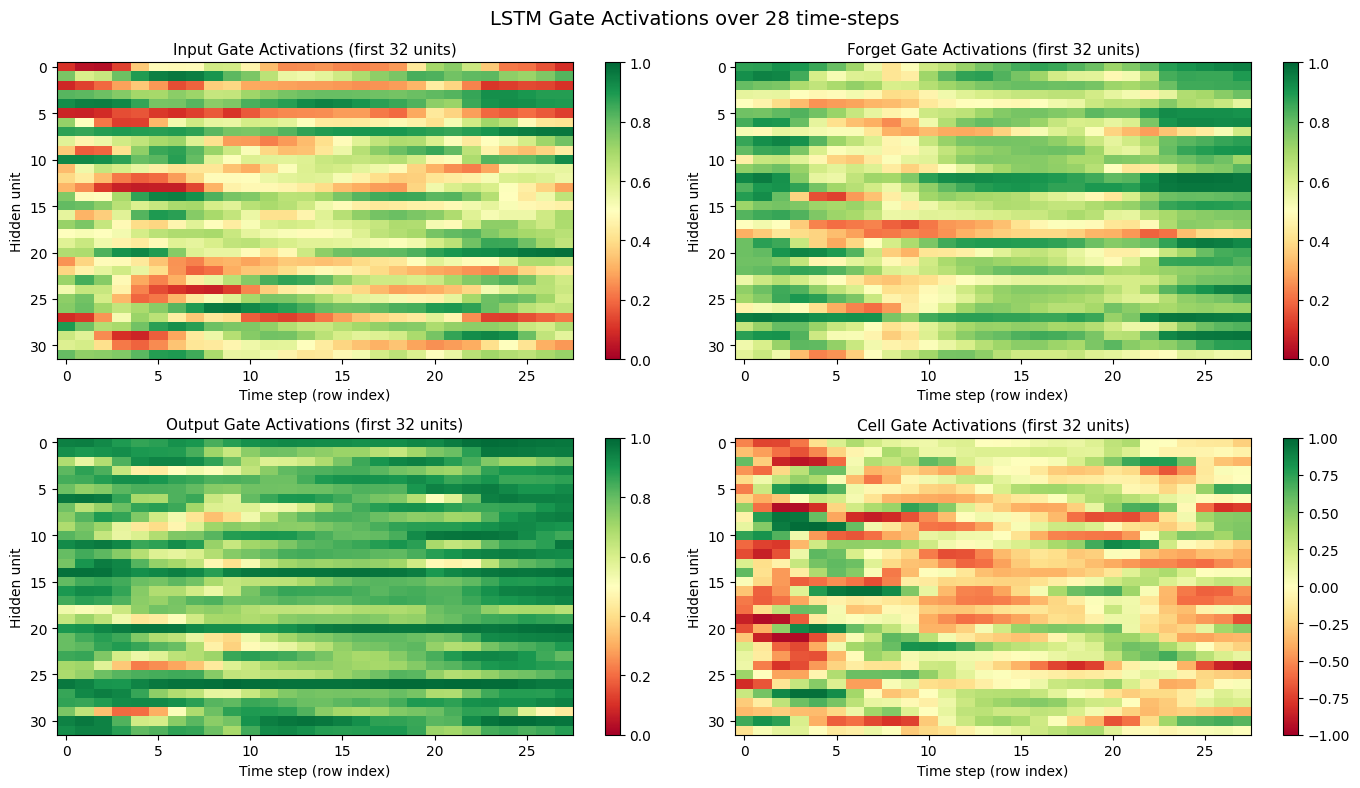

In [14]:
# ─── PS2 Task (f): Gate Activation Visualization ──────────────────────────────
print('=== PS2(f): LSTM Gate Visualization ===')

# Use the trained single-layer LSTM
lstm_1l = lstm_models['LSTM-1L']
# Remove DataParallel wrapper if needed
inner = lstm_1l.module if hasattr(lstm_1l, 'module') else lstm_1l

sample, _ = next(iter(mnist_loader_test))
sample = sample.squeeze(1)[:4].to(device)  # 4 samples

gates = inner.get_gates(sample)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
gate_names = ['input', 'forget', 'output', 'cell']
colors     = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

for idx, (gname, ax, col) in enumerate(zip(gate_names, axes.flat, colors)):
    gate_matrix = np.array([g[gname] for g in gates])  # (T, H)
    im = ax.imshow(gate_matrix.T[:32, :], aspect='auto', cmap='RdYlGn',
                   vmin=0 if gname != 'cell' else -1, vmax=1)
    ax.set_title(f'{gname.capitalize()} Gate Activations (first 32 units)', fontsize=11)
    ax.set_xlabel('Time step (row index)'); ax.set_ylabel('Hidden unit')
    plt.colorbar(im, ax=ax)

plt.suptitle('LSTM Gate Activations over 28 time-steps', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/PS2f_gate_activations.png', dpi=120, bbox_inches='tight')
plt.show()

=== PS2(g,h): LSTM Hidden Units & Dropout Analysis ===
[H64_D0.0] Epoch 01/8 | Train Loss: 0.5819 Acc: 81.06% | Val Loss: 0.1801 Acc: 94.87% | Time: 8.7s
[H64_D0.0] Epoch 02/8 | Train Loss: 0.1457 Acc: 95.72% | Val Loss: 0.1166 Acc: 96.47% | Time: 8.8s
[H64_D0.0] Epoch 03/8 | Train Loss: 0.1055 Acc: 96.86% | Val Loss: 0.0927 Acc: 97.21% | Time: 8.7s
[H64_D0.0] Epoch 04/8 | Train Loss: 0.0816 Acc: 97.53% | Val Loss: 0.0745 Acc: 97.82% | Time: 8.8s
[H64_D0.0] Epoch 05/8 | Train Loss: 0.0655 Acc: 98.04% | Val Loss: 0.0590 Acc: 98.29% | Time: 8.7s
[H64_D0.0] Epoch 06/8 | Train Loss: 0.0556 Acc: 98.30% | Val Loss: 0.0722 Acc: 97.78% | Time: 8.7s
[H64_D0.0] Epoch 07/8 | Train Loss: 0.0461 Acc: 98.60% | Val Loss: 0.0550 Acc: 98.38% | Time: 8.8s
[H64_D0.0] Epoch 08/8 | Train Loss: 0.0420 Acc: 98.75% | Val Loss: 0.0523 Acc: 98.35% | Time: 8.8s
[H64_D0.2] Epoch 01/8 | Train Loss: 0.6448 Acc: 78.98% | Val Loss: 0.1728 Acc: 95.09% | Time: 8.7s
[H64_D0.2] Epoch 02/8 | Train Loss: 0.1621 Acc: 95.30%

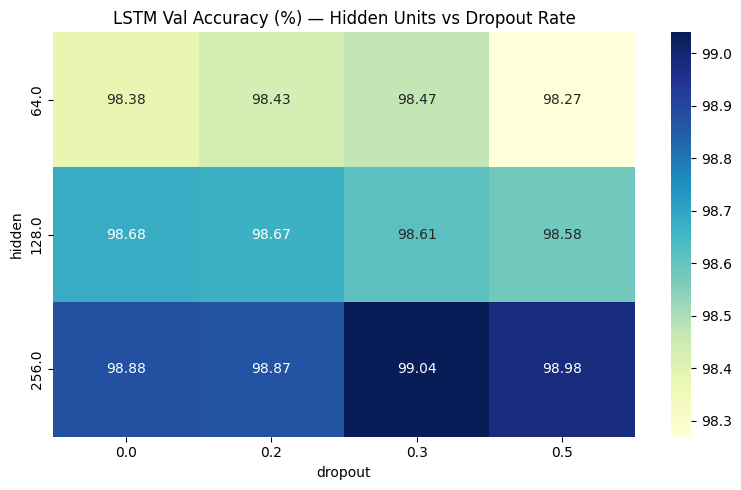

In [15]:
# ─── PS2 Task (g,h): Hidden Units & Dropout ───────────────────────────────────
print('=== PS2(g,h): LSTM Hidden Units & Dropout Analysis ===')

dropout_results = {}
for hidden in [64, 128, 256]:
    for drop in [0.0, 0.2, 0.3, 0.5]:
        key = f'H{hidden}_D{drop}'
        m = to_device(LSTMModel(hidden_size=hidden, num_layers=2,
                                num_classes=10, dropout=drop))
        h = train_model(m, mnist_loader_train, mnist_loader_test,
                        epochs=8, label=key)
        dropout_results[key] = {
            'hidden': hidden, 'dropout': drop,
            'best_val_acc': max(h['val_acc']),
            'train_acc': max(h['train_acc'])
        }

df_drop = pd.DataFrame(dropout_results).T
print('\nDropout + Hidden Units Results:')
print(df_drop.to_string())

# Heatmap
pivot = df_drop.pivot(index='hidden', columns='dropout', values='best_val_acc').astype(float)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('LSTM Val Accuracy (%) — Hidden Units vs Dropout Rate')
plt.tight_layout()
plt.savefig('/kaggle/working/PS2gh_dropout_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

=== PS2(i): LSTM vs Vanilla RNN ===
[RNN] Epoch 01/10 | Train Loss: 0.6946 Acc: 76.69% | Val Loss: 0.3644 Acc: 88.86% | Time: 8.4s
[RNN] Epoch 02/10 | Train Loss: 0.2785 Acc: 91.94% | Val Loss: 0.2486 Acc: 92.68% | Time: 8.2s
[RNN] Epoch 03/10 | Train Loss: 0.1961 Acc: 94.50% | Val Loss: 0.1563 Acc: 95.62% | Time: 8.4s
[RNN] Epoch 04/10 | Train Loss: 0.1609 Acc: 95.45% | Val Loss: 0.1446 Acc: 95.93% | Time: 8.4s
[RNN] Epoch 05/10 | Train Loss: 0.1333 Acc: 96.26% | Val Loss: 0.1101 Acc: 96.90% | Time: 8.5s
[RNN] Epoch 06/10 | Train Loss: 0.1247 Acc: 96.44% | Val Loss: 0.1190 Acc: 96.68% | Time: 8.4s
[RNN] Epoch 07/10 | Train Loss: 0.1162 Acc: 96.68% | Val Loss: 0.1041 Acc: 97.15% | Time: 8.4s
[RNN] Epoch 08/10 | Train Loss: 0.1046 Acc: 96.96% | Val Loss: 0.1153 Acc: 96.52% | Time: 8.4s
[RNN] Epoch 09/10 | Train Loss: 0.0939 Acc: 97.34% | Val Loss: 0.0890 Acc: 97.65% | Time: 8.4s
[RNN] Epoch 10/10 | Train Loss: 0.0913 Acc: 97.47% | Val Loss: 0.1432 Acc: 96.21% | Time: 8.5s
[LSTM] Epoch 0

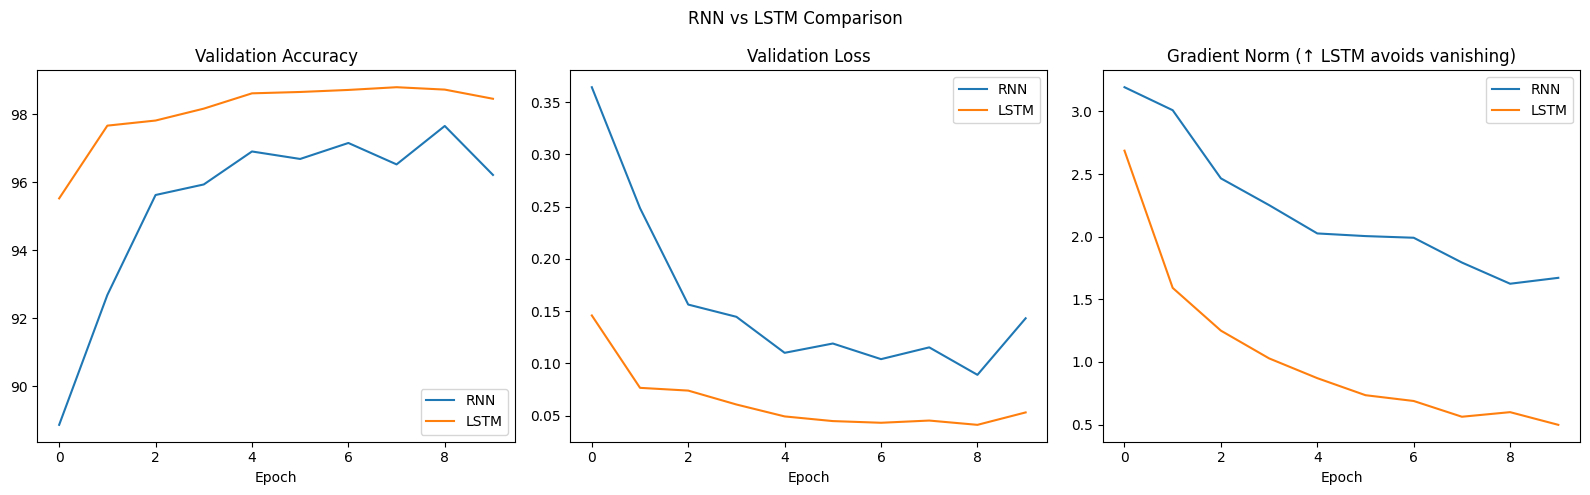

In [16]:
# ─── PS2 Task (i): LSTM vs Vanilla RNN Comparison ─────────────────────────────
print('=== PS2(i): LSTM vs Vanilla RNN ===')

m_rnn_cmp  = to_device(VanillaRNNPyTorch(hidden_size=128, num_layers=2, num_classes=10))
m_lstm_cmp = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))

h_rnn_cmp  = train_model(m_rnn_cmp,  mnist_loader_train, mnist_loader_test, epochs=10, label='RNN',  track_gradients=True)
h_lstm_cmp = train_model(m_lstm_cmp, mnist_loader_train, mnist_loader_test, epochs=10, label='LSTM', track_gradients=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(h_rnn_cmp['val_acc'], label='RNN')
axes[0].plot(h_lstm_cmp['val_acc'], label='LSTM')
axes[0].set_title('Validation Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(h_rnn_cmp['val_loss'], label='RNN')
axes[1].plot(h_lstm_cmp['val_loss'], label='LSTM')
axes[1].set_title('Validation Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')

if 'grad_norms' in h_rnn_cmp and 'grad_norms' in h_lstm_cmp:
    axes[2].plot(h_rnn_cmp['grad_norms'], label='RNN')
    axes[2].plot(h_lstm_cmp['grad_norms'], label='LSTM')
    axes[2].set_title('Gradient Norm (↑ LSTM avoids vanishing)'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('RNN vs LSTM Comparison')
plt.tight_layout()
plt.savefig('/kaggle/working/PS2i_rnn_vs_lstm.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Problem Statement 3 — GRU

In [17]:
# ─── GRU Model ────────────────────────────────────────────────────────────────
class GRUModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(self.dropout(out[:, -1, :]))

print('GRU model defined.')

GRU model defined.


In [18]:
# ─── PS3 Task (j,l): GRU vs LSTM — Stacked Layers ────────────────────────────
print('=== PS3(j,l): GRU vs LSTM Comparison across Layers ===')

gru_results  = {}
lstm_results = {}

for n in [1, 2, 3]:
    t0 = time.time()
    m_gru  = to_device(GRUModel(hidden_size=128, num_layers=n, num_classes=10))
    h_gru  = train_model(m_gru, mnist_loader_train, mnist_loader_test, epochs=8, label=f'GRU-{n}L')
    gru_train_time = time.time() - t0

    t0 = time.time()
    m_lstm = to_device(LSTMModel(hidden_size=128, num_layers=n, num_classes=10))
    h_lstm = train_model(m_lstm, mnist_loader_train, mnist_loader_test, epochs=8, label=f'LSTM-{n}L')
    lstm_train_time = time.time() - t0

    gru_results[f'{n}-layer'] = {
        'best_acc': max(h_gru['val_acc']),
        'params': count_parameters(m_gru),
        'total_time': gru_train_time,
        'avg_epoch_ms': np.mean(h_gru['epoch_time'])*1000
    }
    lstm_results[f'{n}-layer'] = {
        'best_acc': max(h_lstm['val_acc']),
        'params': count_parameters(m_lstm),
        'total_time': lstm_train_time,
        'avg_epoch_ms': np.mean(h_lstm['epoch_time'])*1000
    }

df_gru  = pd.DataFrame(gru_results).T
df_lstm = pd.DataFrame(lstm_results).T
print('\nGRU Results:')
print(df_gru.to_string())
print('\nLSTM Results:')
print(df_lstm.to_string())

=== PS3(j,l): GRU vs LSTM Comparison across Layers ===
[GRU-1L] Epoch 01/8 | Train Loss: 0.6338 Acc: 79.36% | Val Loss: 0.1910 Acc: 94.29% | Time: 8.2s
[GRU-1L] Epoch 02/8 | Train Loss: 0.1496 Acc: 95.63% | Val Loss: 0.1033 Acc: 97.01% | Time: 8.2s
[GRU-1L] Epoch 03/8 | Train Loss: 0.0997 Acc: 96.99% | Val Loss: 0.0858 Acc: 97.45% | Time: 8.1s
[GRU-1L] Epoch 04/8 | Train Loss: 0.0763 Acc: 97.69% | Val Loss: 0.0903 Acc: 97.07% | Time: 8.1s
[GRU-1L] Epoch 05/8 | Train Loss: 0.0615 Acc: 98.13% | Val Loss: 0.0742 Acc: 97.79% | Time: 8.1s
[GRU-1L] Epoch 06/8 | Train Loss: 0.0492 Acc: 98.55% | Val Loss: 0.0607 Acc: 98.10% | Time: 8.2s
[GRU-1L] Epoch 07/8 | Train Loss: 0.0438 Acc: 98.66% | Val Loss: 0.0560 Acc: 98.31% | Time: 8.2s
[GRU-1L] Epoch 08/8 | Train Loss: 0.0377 Acc: 98.85% | Val Loss: 0.0607 Acc: 98.10% | Time: 8.0s
[LSTM-1L] Epoch 01/8 | Train Loss: 0.5135 Acc: 83.29% | Val Loss: 0.1771 Acc: 94.57% | Time: 8.3s
[LSTM-1L] Epoch 02/8 | Train Loss: 0.1326 Acc: 96.14% | Val Loss: 0.103

=== PS3(k): Computational Efficiency ===


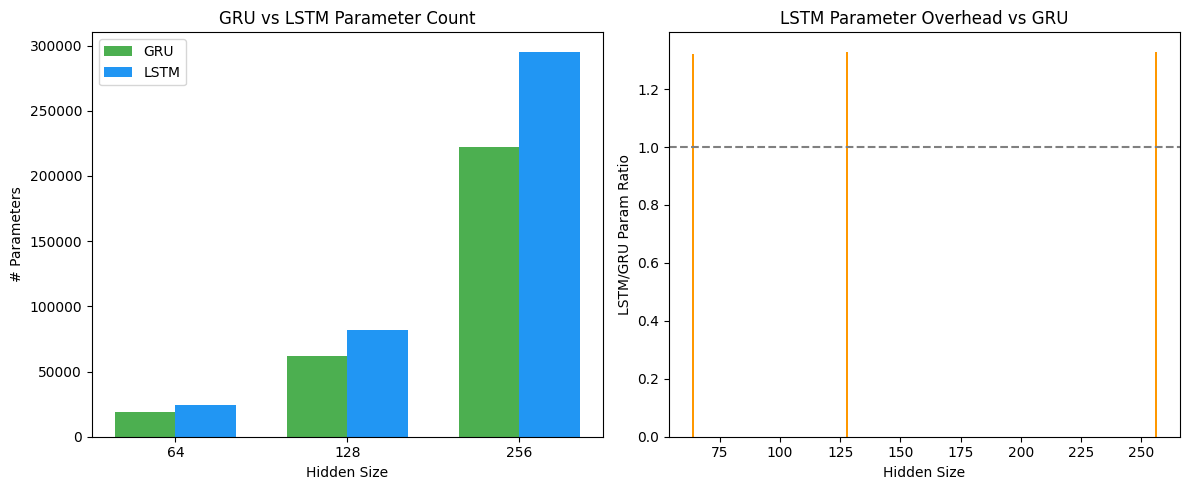

GRU/LSTM ratio: ~1.33x fewer params in GRU vs LSTM

PS3(m) Discussion: Prefer GRU when:
  - Dataset is small (less likely to overfit with fewer params)
  - Faster training/inference needed
  - Performance difference is negligible (empirically close on short sequences)
  Prefer LSTM when: very long sequences, or when cell state finer control matters


In [19]:
# ─── PS3 Task (k): Computational Efficiency: FLOPs & Memory ──────────────────
print('=== PS3(k): Computational Efficiency ===')

# Parameter count is a proxy for computational cost
# GRU has 3 gates: reset, update, new → 3×(input+hidden)×hidden params
# LSTM has 4 gates: input, forget, cell, output → 4×(input+hidden)×hidden params

hidden_sizes = [64, 128, 256]
gru_params, lstm_params = [], []
for h in hidden_sizes:
    gru_params.append(count_parameters(GRUModel(hidden_size=h, num_layers=1)))
    lstm_params.append(count_parameters(LSTMModel(hidden_size=h, num_layers=1)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(hidden_sizes))
w = 0.35
axes[0].bar(x - w/2, gru_params,  w, label='GRU',  color='#4CAF50')
axes[0].bar(x + w/2, lstm_params, w, label='LSTM', color='#2196F3')
axes[0].set_xticks(x); axes[0].set_xticklabels(hidden_sizes)
axes[0].set_xlabel('Hidden Size'); axes[0].set_ylabel('# Parameters')
axes[0].set_title('GRU vs LSTM Parameter Count')
axes[0].legend()

# Ratio
ratios = [l/g for l,g in zip(lstm_params, gru_params)]
axes[1].bar(hidden_sizes, ratios, color='#FF9800')
axes[1].axhline(y=1.0, color='gray', linestyle='--')
axes[1].set_xlabel('Hidden Size'); axes[1].set_ylabel('LSTM/GRU Param Ratio')
axes[1].set_title('LSTM Parameter Overhead vs GRU')

plt.tight_layout()
plt.savefig('/kaggle/working/PS3k_efficiency.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'GRU/LSTM ratio: ~{np.mean(ratios):.2f}x fewer params in GRU vs LSTM')
print('\nPS3(m) Discussion: Prefer GRU when:')
print('  - Dataset is small (less likely to overfit with fewer params)')
print('  - Faster training/inference needed')
print('  - Performance difference is negligible (empirically close on short sequences)')
print('  Prefer LSTM when: very long sequences, or when cell state finer control matters')

---
## Problem Statement 4 — Bidirectional LSTM & GRU

In [20]:
# ─── Bidirectional Models ─────────────────────────────────────────────────────
class BiRNNModel(nn.Module):
    """
    Bidirectional LSTM or GRU.
    merge_mode: 'concat' or 'avg'
    rnn_type:   'lstm' or 'gru'
    """
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, rnn_type='lstm', merge_mode='concat', dropout=0.0):
        super().__init__()
        self.merge_mode = merge_mode
        RNNClass = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn = RNNClass(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        # After BiLSTM: output is hidden_size*2 (concat) or hidden_size (avg)
        fc_in = hidden_size * 2 if merge_mode == 'concat' else hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(fc_in, num_classes)
        self.hidden_size = hidden_size

    def forward(self, x):
        out, _ = self.rnn(x)   # out: (B, T, 2*H)
        last = out[:, -1, :]   # (B, 2*H)
        if self.merge_mode == 'avg':
            # Split and average the two directions
            fwd = last[:, :self.hidden_size]
            bwd = last[:, self.hidden_size:]
            last = (fwd + bwd) / 2
        return self.fc(self.dropout(last))

print('Bidirectional models defined.')

Bidirectional models defined.


=== PS4: Bidirectional Experiments ===
[UniLSTM] Epoch 01/10 | Train Loss: 0.4923 Acc: 83.62% | Val Loss: 0.1383 Acc: 95.74% | Time: 8.7s
[UniLSTM] Epoch 02/10 | Train Loss: 0.1072 Acc: 96.76% | Val Loss: 0.0845 Acc: 97.34% | Time: 8.7s
[UniLSTM] Epoch 03/10 | Train Loss: 0.0673 Acc: 98.00% | Val Loss: 0.0640 Acc: 98.11% | Time: 8.7s
[UniLSTM] Epoch 04/10 | Train Loss: 0.0551 Acc: 98.33% | Val Loss: 0.0502 Acc: 98.49% | Time: 8.6s
[UniLSTM] Epoch 05/10 | Train Loss: 0.0456 Acc: 98.56% | Val Loss: 0.0533 Acc: 98.41% | Time: 8.8s
[UniLSTM] Epoch 06/10 | Train Loss: 0.0378 Acc: 98.88% | Val Loss: 0.0462 Acc: 98.69% | Time: 8.7s
[UniLSTM] Epoch 07/10 | Train Loss: 0.0302 Acc: 99.05% | Val Loss: 0.0484 Acc: 98.39% | Time: 8.7s
[UniLSTM] Epoch 08/10 | Train Loss: 0.0292 Acc: 99.09% | Val Loss: 0.0450 Acc: 98.75% | Time: 8.7s
[UniLSTM] Epoch 09/10 | Train Loss: 0.0265 Acc: 99.15% | Val Loss: 0.0384 Acc: 98.88% | Time: 8.7s
[UniLSTM] Epoch 10/10 | Train Loss: 0.0223 Acc: 99.29% | Val Loss: 0.0

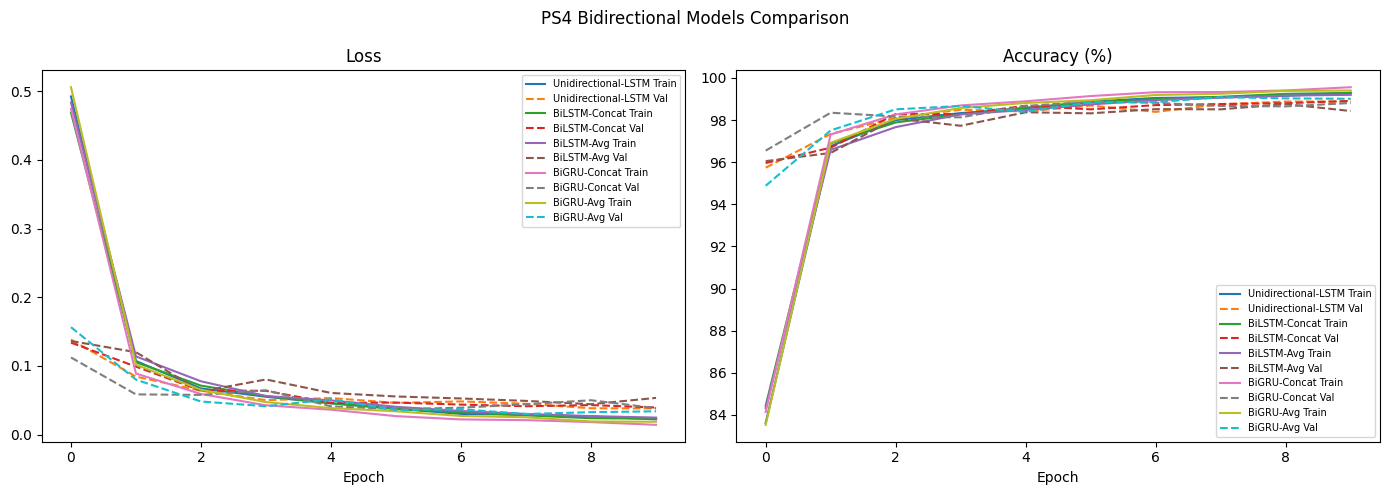


Best Validation Accuracies:
  Unidirectional-LSTM: 98.88%  Params: 214,282
  BiLSTM-Concat: 98.91%  Params: 559,626
  BiLSTM-Avg: 98.76%  Params: 558,346
  BiGRU-Concat: 98.88%  Params: 420,362
  BiGRU-Avg: 99.09%  Params: 419,082


In [21]:
# ─── PS4 Tasks (n,o,p,q) ──────────────────────────────────────────────────────
print('=== PS4: Bidirectional Experiments ===')

bi_configs = [
    ('BiLSTM-Concat',  'lstm', 'concat'),
    ('BiLSTM-Avg',     'lstm', 'avg'),
    ('BiGRU-Concat',   'gru',  'concat'),
    ('BiGRU-Avg',      'gru',  'avg'),
]

# Also include unidirectional LSTM for comparison
m_uni_lstm = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))
h_uni_lstm = train_model(m_uni_lstm, mnist_loader_train, mnist_loader_test,
                         epochs=10, label='UniLSTM')

bi_histories = {'Unidirectional-LSTM': h_uni_lstm}
bi_models    = {'Unidirectional-LSTM': m_uni_lstm}

for name, rnn_type, merge in bi_configs:
    m = to_device(BiRNNModel(hidden_size=128, num_layers=2, num_classes=10,
                             rnn_type=rnn_type, merge_mode=merge))
    h = train_model(m, mnist_loader_train, mnist_loader_test, epochs=10, label=name)
    bi_histories[name] = h
    bi_models[name]    = m

plot_history(bi_histories, title='PS4 Bidirectional Models Comparison')
print('\nBest Validation Accuracies:')
for k, h in bi_histories.items():
    print(f'  {k}: {max(h["val_acc"]):.2f}%  Params: {count_parameters(bi_models[k]):,}')

=== PS4(q): Analysis — Does Bidirectional Help? ===


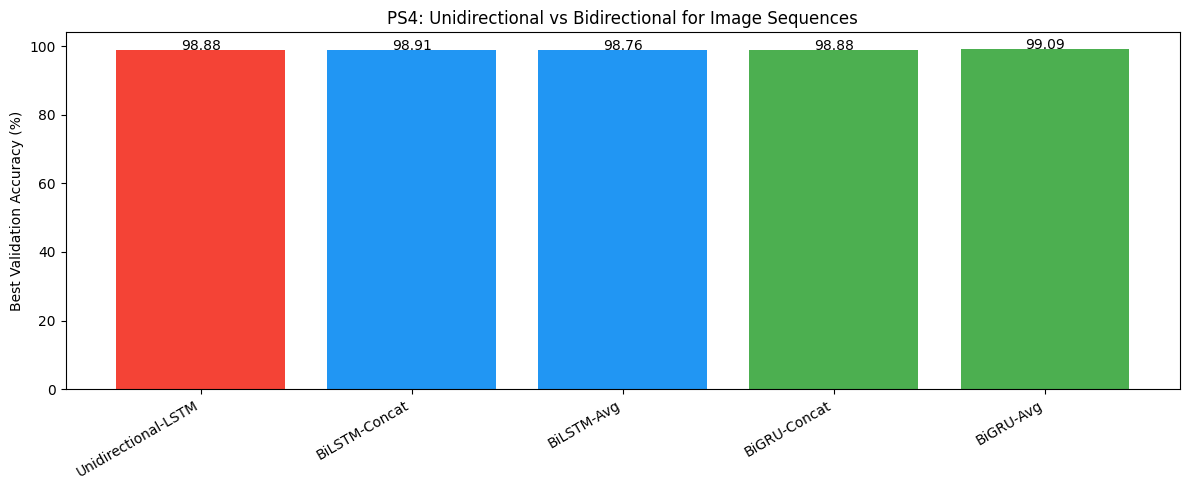


Insight: Bidirectional processing can help for images because:
  - Forward: processes top-to-bottom (stroke beginning context)
  - Backward: processes bottom-to-top (captures global structure from end)
  However, gains may be marginal vs extra parameters for simple digit recognition.


In [22]:
# ─── PS4 Task (q): Does Bidirectional Help for Image Sequences? ───────────────
print('=== PS4(q): Analysis — Does Bidirectional Help? ===')

bi_accs   = {k: max(h['val_acc']) for k, h in bi_histories.items()}
names     = list(bi_accs.keys())
accs      = list(bi_accs.values())

plt.figure(figsize=(12, 5))
colors_bar = ['#F44336' if 'Uni' in n else ('#2196F3' if 'LSTM' in n else '#4CAF50') for n in names]
bars = plt.bar(names, accs, color=colors_bar)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('PS4: Unidirectional vs Bidirectional for Image Sequences')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{acc:.2f}', ha='center')
plt.tight_layout()
plt.savefig('/kaggle/working/PS4q_bidirectional.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nInsight: Bidirectional processing can help for images because:')
print('  - Forward: processes top-to-bottom (stroke beginning context)')
print('  - Backward: processes bottom-to-top (captures global structure from end)')
print('  However, gains may be marginal vs extra parameters for simple digit recognition.')

---
## Problem Statement 5 — CNN + LSTM Hybrid

In [23]:
# ─── Hybrid Architecture A: CNN Feature Extractor + LSTM ─────────────────────
class CNNLSTMModel(nn.Module):
    """
    Architecture A: CNN extracts spatial features from the full image,
    then the feature vector is fed through a projection into LSTM over time-steps.
    Each row is processed through shared CNN filters → sequence of feature vectors.
    """
    def __init__(self, hidden_size=128, num_classes=10):
        super().__init__()
        # CNN processes each row (1D conv along column axis)
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)  # 28 → 14
        )
        cnn_out_size = 64 * 14
        self.lstm = nn.LSTM(cnn_out_size, hidden_size, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, 28, 28)
        B, T, W = x.size()
        # Process each row with CNN
        x_reshaped = x.reshape(B * T, 1, W)       # (B*T, 1, 28)
        cnn_out = self.cnn(x_reshaped)              # (B*T, 64, 14)
        cnn_out = cnn_out.view(B, T, -1)            # (B, T, 64*14)
        # Feed to LSTM
        lstm_out, _ = self.lstm(cnn_out)
        return self.fc(lstm_out[:, -1, :])


# ─── Hybrid Architecture B: Time-Distributed CNN + LSTM ──────────────────────
class TimeDist2DCNN_LSTM(nn.Module):
    """
    Architecture C: 2D CNN on the full image for spatial features,
    then reshape output as a sequence for LSTM.
    """
    def __init__(self, hidden_size=128, num_classes=10):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                             # 28 → 14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)                              # 14 → 7
        )
        # After 2 poolings: (B, 64, 7, 7)
        # Treat 7 columns as time-steps, each with 64*7 features
        self.lstm = nn.LSTM(64 * 7, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, 28, 28) → need (B, 1, 28, 28)
        x = x.unsqueeze(1)
        cnn_out = self.cnn(x)                # (B, 64, 7, 7)
        B, C, H, W = cnn_out.size()
        # Reshape: treat H as time-steps
        seq = cnn_out.permute(0, 2, 1, 3).reshape(B, H, C * W)  # (B, 7, 64*7)
        out, _ = self.lstm(seq)
        return self.fc(out[:, -1, :])


# ─── Pure CNN Baseline ────────────────────────────────────────────────────────
class PureCNNModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*7*7, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)          # (B, 1, 28, 28)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

print('Hybrid models defined.')

Hybrid models defined.


=== PS5(r,s): CNN+LSTM Hybrid Training ===
--- Pure CNN ---
[PureCNN] Epoch 01/10 | Train Loss: 0.2204 Acc: 93.26% | Val Loss: 0.0538 Acc: 98.28% | Time: 10.5s
[PureCNN] Epoch 02/10 | Train Loss: 0.0677 Acc: 97.97% | Val Loss: 0.0332 Acc: 98.87% | Time: 9.8s
[PureCNN] Epoch 03/10 | Train Loss: 0.0501 Acc: 98.49% | Val Loss: 0.0300 Acc: 99.09% | Time: 9.9s
[PureCNN] Epoch 04/10 | Train Loss: 0.0415 Acc: 98.71% | Val Loss: 0.0210 Acc: 99.24% | Time: 9.8s
[PureCNN] Epoch 05/10 | Train Loss: 0.0357 Acc: 98.83% | Val Loss: 0.0245 Acc: 99.14% | Time: 9.8s
[PureCNN] Epoch 06/10 | Train Loss: 0.0304 Acc: 98.98% | Val Loss: 0.0232 Acc: 99.21% | Time: 9.9s
[PureCNN] Epoch 07/10 | Train Loss: 0.0278 Acc: 99.09% | Val Loss: 0.0227 Acc: 99.22% | Time: 9.9s
[PureCNN] Epoch 08/10 | Train Loss: 0.0255 Acc: 99.18% | Val Loss: 0.0207 Acc: 99.30% | Time: 9.8s
[PureCNN] Epoch 09/10 | Train Loss: 0.0222 Acc: 99.26% | Val Loss: 0.0256 Acc: 99.17% | Time: 9.9s
[PureCNN] Epoch 10/10 | Train Loss: 0.0208 Acc: 

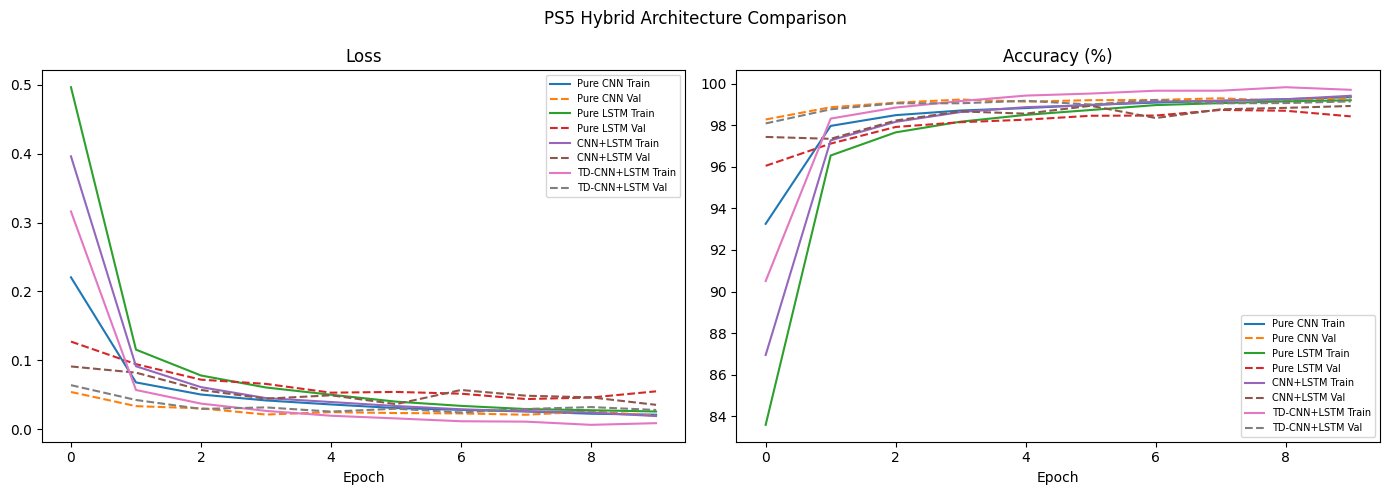

In [24]:
# ─── PS5 Tasks (r,s): Train & Compare Hybrid Models ──────────────────────────
print('=== PS5(r,s): CNN+LSTM Hybrid Training ===')

# Pure CNN and Pure LSTM baselines
m_cnn       = to_device(PureCNNModel(num_classes=10))
m_pure_lstm = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))
m_cnn_lstm  = to_device(CNNLSTMModel(hidden_size=128, num_classes=10))
m_td_cnn    = to_device(TimeDist2DCNN_LSTM(hidden_size=128, num_classes=10))

print('--- Pure CNN ---')
h_cnn = train_model(m_cnn, mnist_loader_train, mnist_loader_test, epochs=10, label='PureCNN')

print('--- Pure LSTM ---')
h_pure_lstm = train_model(m_pure_lstm, mnist_loader_train, mnist_loader_test, epochs=10, label='PureLSTM')

print('--- CNN+LSTM Hybrid ---')
h_cnn_lstm = train_model(m_cnn_lstm, mnist_loader_train, mnist_loader_test, epochs=10, label='CNN-LSTM')

print('--- Time-Distributed CNN+LSTM ---')
h_td = train_model(m_td_cnn, mnist_loader_train, mnist_loader_test, epochs=10, label='TD-CNN-LSTM')

plot_history({
    'Pure CNN':       h_cnn,
    'Pure LSTM':      h_pure_lstm,
    'CNN+LSTM':       h_cnn_lstm,
    'TD-CNN+LSTM':    h_td
}, title='PS5 Hybrid Architecture Comparison')

=== PS5(t,u): Feature Maps & Trade-offs ===


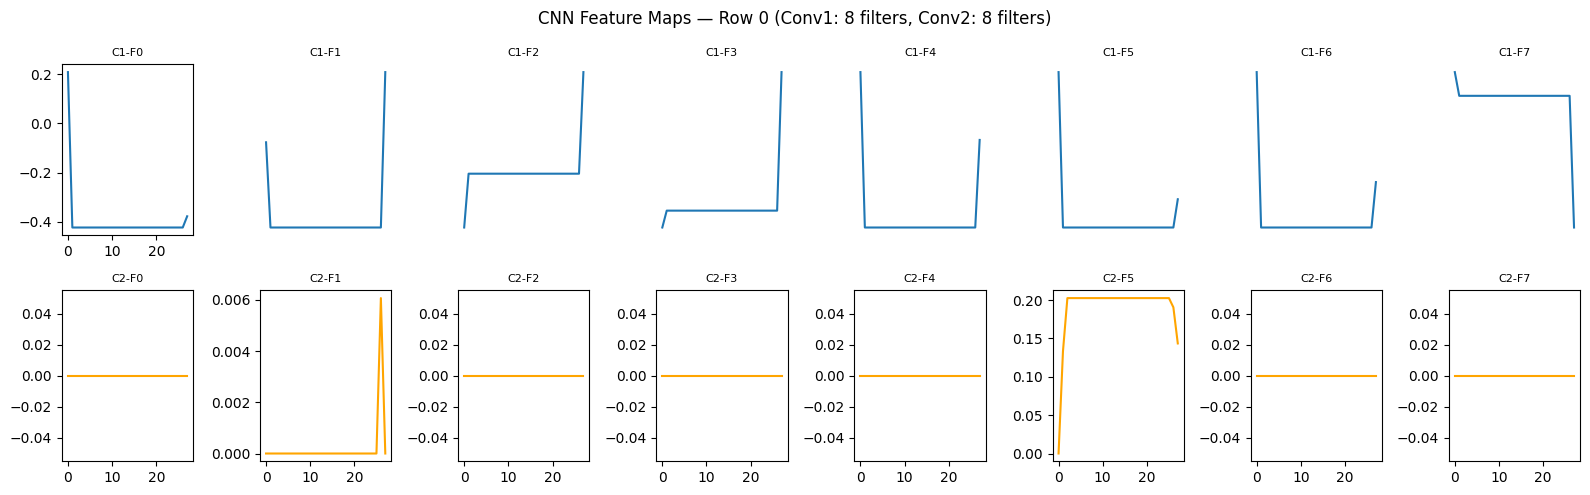


Model                  Params  Best Acc(%) Avg EpochTime(s) Infer(ms/batch)
---------------------------------------------------------------------------
Pure CNN              824,458        99.31            9.90          14.82
Pure LSTM             214,282        98.74            9.00          11.61
CNN+LSTM              665,034        98.94           10.79          25.70
TD-CNN+LSTM           316,042        99.22           10.54          15.76


In [25]:
# ─── PS5 Task (t,u): Feature Maps & Inference Time ───────────────────────────
print('=== PS5(t,u): Feature Maps & Trade-offs ===')

# Visualize CNN feature maps from the hybrid model
inner_cnn_lstm = m_cnn_lstm.module if hasattr(m_cnn_lstm, 'module') else m_cnn_lstm

sample, _ = next(iter(mnist_loader_test))
sample = sample.squeeze(1)[:1].to(device)   # single image

# Extract CNN activations by forward hook
activations = {}
def make_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu()
    return hook

inner_cnn_lstm.cnn[0].register_forward_hook(make_hook('conv1'))
inner_cnn_lstm.cnn[3].register_forward_hook(make_hook('conv2'))

with torch.no_grad():
    _ = m_cnn_lstm(sample)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('CNN Feature Maps — Row 0 (Conv1: 8 filters, Conv2: 8 filters)', fontsize=12)
for i in range(8):
    # conv1: (B*T, 32, 28) → pick first row
    fmap1 = activations['conv1'][0, i].numpy()   # (28,)
    axes[0, i].plot(fmap1)
    axes[0, i].set_title(f'C1-F{i}', fontsize=8)
    axes[0, i].axis('off') if i > 0 else None
    
    fmap2 = activations['conv2'][0, i].numpy()   # (14,)
    axes[1, i].plot(fmap2, color='orange')
    axes[1, i].set_title(f'C2-F{i}', fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/PS5t_feature_maps.png', dpi=120, bbox_inches='tight')
plt.show()

# Trade-off table
hybrid_models = {
    'Pure CNN':     (m_cnn,       h_cnn),
    'Pure LSTM':    (m_pure_lstm, h_pure_lstm),
    'CNN+LSTM':     (m_cnn_lstm,  h_cnn_lstm),
    'TD-CNN+LSTM':  (m_td_cnn,    h_td),
}

print('\n{:<18} {:>10} {:>12} {:>15} {:>14}'.format(
    'Model', 'Params', 'Best Acc(%)', 'Avg EpochTime(s)', 'Infer(ms/batch)'))
print('-' * 75)
for name, (model, hist) in hybrid_models.items():
    params     = count_parameters(model)
    best_acc   = max(hist['val_acc'])
    epoch_time = np.mean(hist['epoch_time'])
    infer_ms   = get_inference_time(model, mnist_loader_test)
    print(f'{name:<18} {params:>10,} {best_acc:>12.2f} {epoch_time:>15.2f} {infer_ms:>14.2f}')

---
## Problem Statement 6 — Hyperparameter Tuning & Regularization

In [26]:
# ─── PS6: Systematic Hyperparameter Tuning ─────────────────────────────────
print('=== PS6: Hyperparameter Tuning ===')
# We use LSTM as the target model, MNIST dataset

# 6a: Learning Rate
print('--- Learning Rate Sweep ---')
lr_results = {}
for lr in [0.1, 0.01, 0.001, 0.0001]:
    m = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))
    h = train_model(m, mnist_loader_train, mnist_loader_test,
                    epochs=8, lr=lr, label=f'LR={lr}')
    lr_results[f'lr={lr}'] = max(h['val_acc'])

print('LR Results:', lr_results)

=== PS6: Hyperparameter Tuning ===
--- Learning Rate Sweep ---
[LR=0.1] Epoch 01/8 | Train Loss: 2.3955 Acc: 10.14% | Val Loss: 2.3464 Acc: 10.09% | Time: 9.2s
[LR=0.1] Epoch 02/8 | Train Loss: 2.3842 Acc: 10.25% | Val Loss: 2.3812 Acc: 10.28% | Time: 9.2s
[LR=0.1] Epoch 03/8 | Train Loss: 2.3795 Acc: 10.35% | Val Loss: 2.3262 Acc: 11.35% | Time: 9.3s
[LR=0.1] Epoch 04/8 | Train Loss: 2.3752 Acc: 9.93% | Val Loss: 2.3889 Acc: 10.28% | Time: 9.4s
[LR=0.1] Epoch 05/8 | Train Loss: 2.3810 Acc: 10.27% | Val Loss: 2.3762 Acc: 10.10% | Time: 9.3s
[LR=0.1] Epoch 06/8 | Train Loss: 2.3736 Acc: 10.15% | Val Loss: 2.3612 Acc: 9.82% | Time: 9.1s
[LR=0.1] Epoch 07/8 | Train Loss: 2.3839 Acc: 10.13% | Val Loss: 2.4057 Acc: 9.82% | Time: 9.2s
[LR=0.1] Epoch 08/8 | Train Loss: 2.3841 Acc: 10.00% | Val Loss: 2.3972 Acc: 11.35% | Time: 9.1s
  Early stopping at epoch 8
[LR=0.01] Epoch 01/8 | Train Loss: 0.3639 Acc: 87.93% | Val Loss: 0.1217 Acc: 96.42% | Time: 9.2s
[LR=0.01] Epoch 02/8 | Train Loss: 0.1

In [27]:
# 6b: Batch Size
print('--- Batch Size Sweep ---')
bs_results = {}
for bs in [32, 64, 128, 256]:
    train_ldr = DataLoader(mnist_train, batch_size=bs, shuffle=True, num_workers=4, pin_memory=True)
    m = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))
    h = train_model(m, train_ldr, mnist_loader_test,
                    epochs=8, label=f'BS={bs}')
    bs_results[f'bs={bs}'] = {'best_acc': max(h['val_acc']), 'epoch_time': np.mean(h['epoch_time'])}

print('Batch Size Results:', bs_results)

--- Batch Size Sweep ---
[BS=32] Epoch 01/8 | Train Loss: 0.3018 Acc: 90.28% | Val Loss: 0.0928 Acc: 97.20% | Time: 20.2s
[BS=32] Epoch 02/8 | Train Loss: 0.0842 Acc: 97.49% | Val Loss: 0.0751 Acc: 97.70% | Time: 20.2s
[BS=32] Epoch 03/8 | Train Loss: 0.0611 Acc: 98.16% | Val Loss: 0.0637 Acc: 98.09% | Time: 20.5s
[BS=32] Epoch 04/8 | Train Loss: 0.0488 Acc: 98.50% | Val Loss: 0.0639 Acc: 98.04% | Time: 20.3s
[BS=32] Epoch 05/8 | Train Loss: 0.0394 Acc: 98.83% | Val Loss: 0.0513 Acc: 98.53% | Time: 20.3s
[BS=32] Epoch 06/8 | Train Loss: 0.0343 Acc: 98.92% | Val Loss: 0.0476 Acc: 98.64% | Time: 20.3s
[BS=32] Epoch 07/8 | Train Loss: 0.0291 Acc: 99.10% | Val Loss: 0.0397 Acc: 98.85% | Time: 20.3s
[BS=32] Epoch 08/8 | Train Loss: 0.0269 Acc: 99.16% | Val Loss: 0.0415 Acc: 98.73% | Time: 20.3s
[BS=64] Epoch 01/8 | Train Loss: 0.3635 Acc: 88.15% | Val Loss: 0.1159 Acc: 96.59% | Time: 12.5s
[BS=64] Epoch 02/8 | Train Loss: 0.0906 Acc: 97.29% | Val Loss: 0.0653 Acc: 98.06% | Time: 12.7s
[BS=6

--- Optimizer Comparison ---
[SGD] Epoch 01/10 | Train Loss: 2.3025 Acc: 10.39% | Val Loss: 2.3002 Acc: 13.85% | Time: 9.2s
[SGD] Epoch 02/10 | Train Loss: 2.2990 Acc: 11.43% | Val Loss: 2.2976 Acc: 11.35% | Time: 9.1s
[SGD] Epoch 03/10 | Train Loss: 2.2967 Acc: 11.24% | Val Loss: 2.2952 Acc: 11.35% | Time: 9.1s
[SGD] Epoch 04/10 | Train Loss: 2.2940 Acc: 11.24% | Val Loss: 2.2919 Acc: 11.36% | Time: 9.2s
[SGD] Epoch 05/10 | Train Loss: 2.2898 Acc: 11.29% | Val Loss: 2.2864 Acc: 11.51% | Time: 9.1s
[SGD] Epoch 06/10 | Train Loss: 2.2818 Acc: 11.60% | Val Loss: 2.2739 Acc: 12.52% | Time: 9.0s
  Early stopping at epoch 6
[ADAM] Epoch 01/10 | Train Loss: 0.4462 Acc: 85.28% | Val Loss: 0.1467 Acc: 95.75% | Time: 9.1s
[ADAM] Epoch 02/10 | Train Loss: 0.1037 Acc: 96.87% | Val Loss: 0.0811 Acc: 97.41% | Time: 9.1s
[ADAM] Epoch 03/10 | Train Loss: 0.0717 Acc: 97.84% | Val Loss: 0.0618 Acc: 98.13% | Time: 9.2s
[ADAM] Epoch 04/10 | Train Loss: 0.0548 Acc: 98.37% | Val Loss: 0.0488 Acc: 98.56% | 

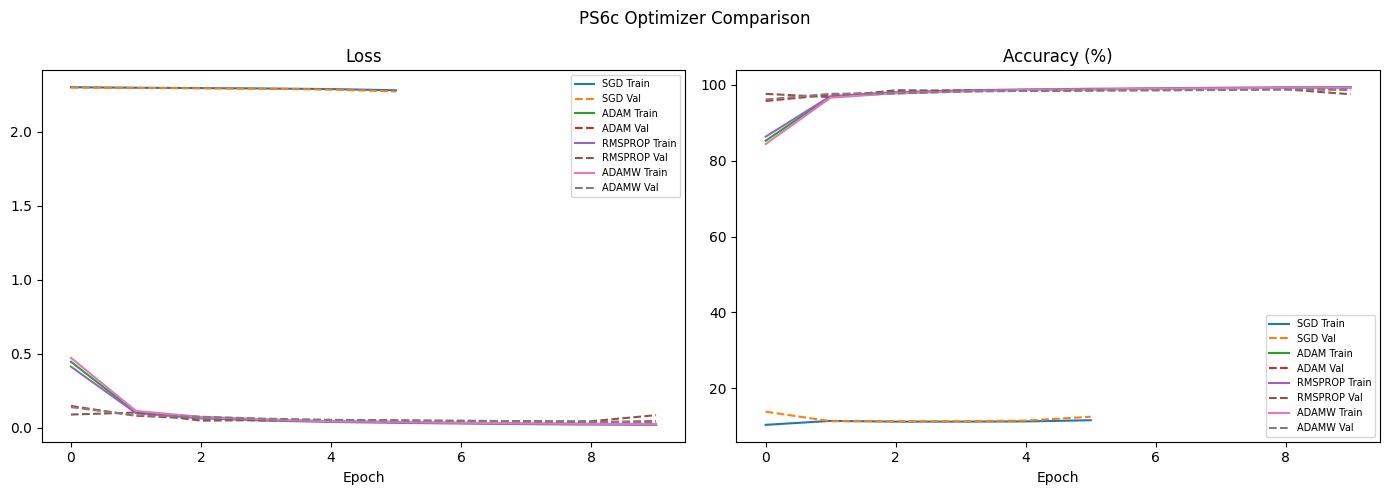

Optimizer Results: {'sgd': 13.85, 'adam': 98.92, 'rmsprop': 98.94, 'adamw': 98.81}


In [28]:
# 6c: Optimizer Comparison
print('--- Optimizer Comparison ---')
opt_results  = {}
opt_histories = {}
for opt_name in ['sgd', 'adam', 'rmsprop', 'adamw']:
    m = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))
    h = train_model(m, mnist_loader_train, mnist_loader_test,
                    epochs=10, optimizer_name=opt_name, label=opt_name.upper())
    opt_results[opt_name]   = max(h['val_acc'])
    opt_histories[opt_name.upper()] = h

plot_history(opt_histories, title='PS6c Optimizer Comparison')
print('Optimizer Results:', opt_results)

--- Gradient Clipping ---
[clip=None] Epoch 01/8 | Train Loss: 0.4808 Acc: 83.96% | Val Loss: 0.1621 Acc: 95.08% | Time: 9.2s
[clip=None] Epoch 02/8 | Train Loss: 0.1162 Acc: 96.57% | Val Loss: 0.0808 Acc: 97.47% | Time: 9.3s
[clip=None] Epoch 03/8 | Train Loss: 0.0750 Acc: 97.72% | Val Loss: 0.0682 Acc: 98.03% | Time: 9.2s
[clip=None] Epoch 04/8 | Train Loss: 0.0564 Acc: 98.25% | Val Loss: 0.0486 Acc: 98.49% | Time: 9.2s
[clip=None] Epoch 05/8 | Train Loss: 0.0476 Acc: 98.57% | Val Loss: 0.0507 Acc: 98.37% | Time: 9.1s
[clip=None] Epoch 06/8 | Train Loss: 0.0378 Acc: 98.78% | Val Loss: 0.0513 Acc: 98.41% | Time: 9.2s
[clip=None] Epoch 07/8 | Train Loss: 0.0341 Acc: 98.93% | Val Loss: 0.0437 Acc: 98.71% | Time: 9.3s
[clip=None] Epoch 08/8 | Train Loss: 0.0298 Acc: 99.04% | Val Loss: 0.0398 Acc: 98.86% | Time: 9.3s
[clip=1.0] Epoch 01/8 | Train Loss: 0.4862 Acc: 84.14% | Val Loss: 0.1240 Acc: 96.30% | Time: 9.3s
[clip=1.0] Epoch 02/8 | Train Loss: 0.1181 Acc: 96.58% | Val Loss: 0.0968 A

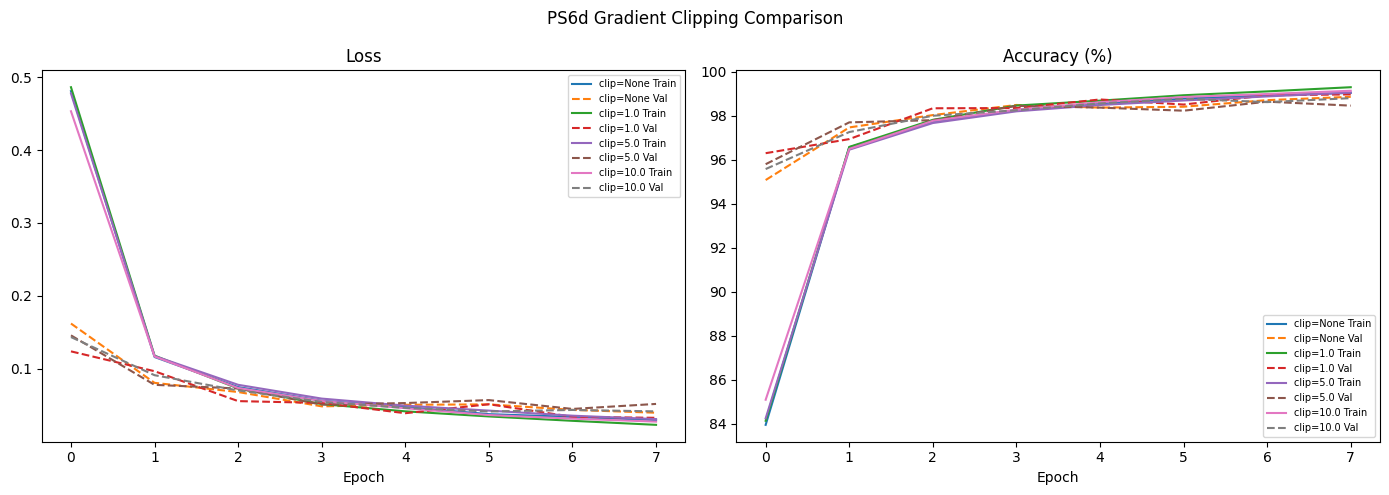

Gradient Clipping Results: {'clip=None': 98.86, 'clip=1.0': 98.97, 'clip=5.0': 98.64, 'clip=10.0': 98.8}


In [29]:
# 6d: Gradient Clipping
print('--- Gradient Clipping ---')
clip_results  = {}
clip_histories = {}
for clip in [None, 1.0, 5.0, 10.0]:
    m = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))
    label = f'clip={clip}'
    h = train_model(m, mnist_loader_train, mnist_loader_test,
                    epochs=8, clip_grad=clip, label=label)
    clip_results[label]     = max(h['val_acc'])
    clip_histories[label]   = h

plot_history(clip_histories, title='PS6d Gradient Clipping Comparison')
print('Gradient Clipping Results:', clip_results)

--- LR Scheduling ---
[sched=None] Epoch 01/10 | Train Loss: 0.4784 Acc: 84.00% | Val Loss: 0.1489 Acc: 95.89% | Time: 10.2s
[sched=None] Epoch 02/10 | Train Loss: 0.1175 Acc: 96.50% | Val Loss: 0.1152 Acc: 96.29% | Time: 9.4s
[sched=None] Epoch 03/10 | Train Loss: 0.0761 Acc: 97.67% | Val Loss: 0.0687 Acc: 98.00% | Time: 9.3s
[sched=None] Epoch 04/10 | Train Loss: 0.0555 Acc: 98.33% | Val Loss: 0.0600 Acc: 98.17% | Time: 9.4s
[sched=None] Epoch 05/10 | Train Loss: 0.0461 Acc: 98.57% | Val Loss: 0.0575 Acc: 98.27% | Time: 9.4s
[sched=None] Epoch 06/10 | Train Loss: 0.0370 Acc: 98.88% | Val Loss: 0.0519 Acc: 98.61% | Time: 9.4s
[sched=None] Epoch 07/10 | Train Loss: 0.0350 Acc: 98.91% | Val Loss: 0.0481 Acc: 98.67% | Time: 9.3s
[sched=None] Epoch 08/10 | Train Loss: 0.0308 Acc: 99.03% | Val Loss: 0.0539 Acc: 98.47% | Time: 9.3s
[sched=None] Epoch 09/10 | Train Loss: 0.0259 Acc: 99.19% | Val Loss: 0.0490 Acc: 98.57% | Time: 9.4s
[sched=None] Epoch 10/10 | Train Loss: 0.0208 Acc: 99.36% |

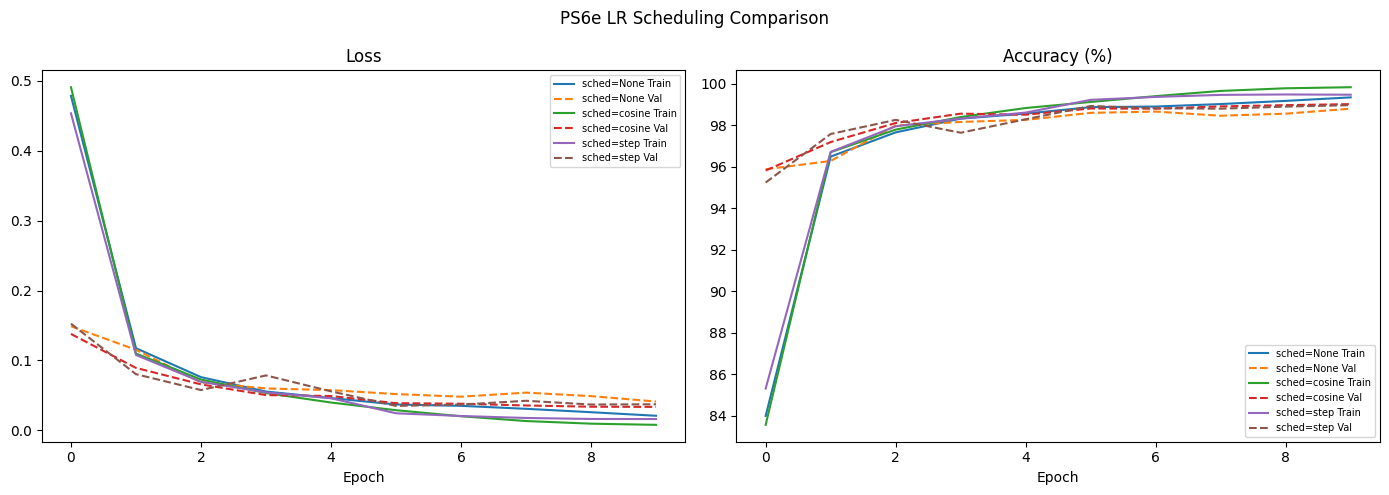

In [30]:
# 6e: Learning Rate Scheduling
print('--- LR Scheduling ---')
sched_histories = {}
for sched in [None, 'cosine', 'step']:
    m = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))
    label = f'sched={sched}'
    h = train_model(m, mnist_loader_train, mnist_loader_test,
                    epochs=10, scheduler_type=sched, label=label)
    sched_histories[label] = h

plot_history(sched_histories, title='PS6e LR Scheduling Comparison')

In [31]:
# 6f: L2 Regularization (Weight Decay)
print('--- L2 Regularization ---')
for wd in [0.0, 1e-4, 1e-3]:
    m = to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10))
    # Use AdamW which properly applies weight decay
    optimizer = optim.AdamW(m.parameters(), lr=0.001, weight_decay=wd)
    # Quick 5-epoch run using manual loop for brevity
    criterion = nn.CrossEntropyLoss()
    best_acc = 0.0
    for ep in range(5):
        m.train()
        for x, y in mnist_loader_train:
            x, y = x.squeeze(1).to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(m(x), y)
            loss.backward(); optimizer.step()
        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in mnist_loader_test:
                x, y = x.squeeze(1).to(device), y.to(device)
                _, pred = m(x).max(1)
                correct += pred.eq(y).sum().item(); total += y.size(0)
        best_acc = max(best_acc, 100.0 * correct / total)
    print(f'  L2 weight_decay={wd:.0e}: Best Acc = {best_acc:.2f}%')

--- L2 Regularization ---
  L2 weight_decay=0e+00: Best Acc = 98.17%
  L2 weight_decay=1e-04: Best Acc = 98.70%
  L2 weight_decay=1e-03: Best Acc = 98.47%


---
## Problem Statement 7 — Comprehensive Comparative Analysis

In [32]:
# ─── PS7: Train Best Configurations of All Architectures for Final Comparison ──
print('=== PS7: Final Comprehensive Comparison ===')
print('Training best-config models on MNIST (10 classes)...')

FINAL_EPOCHS = 15

final_models = {
    'Vanilla-RNN':    to_device(VanillaRNNPyTorch(hidden_size=128, num_layers=2, num_classes=10)),
    'LSTM':           to_device(LSTMModel(hidden_size=128, num_layers=2, num_classes=10, dropout=0.3)),
    'GRU':            to_device(GRUModel(hidden_size=128, num_layers=2, num_classes=10, dropout=0.3)),
    'BiLSTM':         to_device(BiRNNModel(hidden_size=128, num_layers=2, num_classes=10, rnn_type='lstm', merge_mode='concat')),
    'BiGRU':          to_device(BiRNNModel(hidden_size=128, num_layers=2, num_classes=10, rnn_type='gru', merge_mode='concat')),
    'CNN+LSTM':       to_device(CNNLSTMModel(hidden_size=128, num_classes=10)),
    'TD-CNN+LSTM':    to_device(TimeDist2DCNN_LSTM(hidden_size=128, num_classes=10)),
    'Pure-CNN':       to_device(PureCNNModel(num_classes=10)),
}

final_histories = {}
for name, model in final_models.items():
    print(f'\n>>> {name}')
    final_histories[name] = train_model(
        model, mnist_loader_train, mnist_loader_test,
        epochs=FINAL_EPOCHS, optimizer_name='adam', clip_grad=1.0,
        scheduler_type='cosine', label=name
    )

=== PS7: Final Comprehensive Comparison ===
Training best-config models on MNIST (10 classes)...

>>> Vanilla-RNN
[Vanilla-RNN] Epoch 01/15 | Train Loss: 0.7297 Acc: 75.25% | Val Loss: 0.3226 Acc: 90.27% | Time: 8.7s
[Vanilla-RNN] Epoch 02/15 | Train Loss: 0.2616 Acc: 92.21% | Val Loss: 0.1743 Acc: 94.87% | Time: 8.7s
[Vanilla-RNN] Epoch 03/15 | Train Loss: 0.1844 Acc: 94.53% | Val Loss: 0.1675 Acc: 95.35% | Time: 8.8s
[Vanilla-RNN] Epoch 04/15 | Train Loss: 0.1540 Acc: 95.55% | Val Loss: 0.1265 Acc: 96.30% | Time: 8.8s
[Vanilla-RNN] Epoch 05/15 | Train Loss: 0.1237 Acc: 96.45% | Val Loss: 0.1340 Acc: 96.18% | Time: 8.8s
[Vanilla-RNN] Epoch 06/15 | Train Loss: 0.1069 Acc: 96.91% | Val Loss: 0.1048 Acc: 97.25% | Time: 8.9s
[Vanilla-RNN] Epoch 07/15 | Train Loss: 0.0913 Acc: 97.42% | Val Loss: 0.1006 Acc: 97.33% | Time: 8.9s
[Vanilla-RNN] Epoch 08/15 | Train Loss: 0.0751 Acc: 97.83% | Val Loss: 0.0933 Acc: 97.52% | Time: 8.9s
[Vanilla-RNN] Epoch 09/15 | Train Loss: 0.0664 Acc: 98.11% | V

In [33]:
# ─── PS7: Comparison Bar Charts ───────────────────────────────────────────────
comparison_data = {}
for name, model in final_models.items():
    h = final_histories[name]
    comparison_data[name] = {
        'Test Acc (%)':        max(h['val_acc']),
        'Parameters':          count_parameters(model),
        'Avg Epoch Time (s)':  np.mean(h['epoch_time']),
        'Infer Time (ms)':     get_inference_time(model, mnist_loader_test),
        'Convergence Epoch':   int(np.argmax(h['val_acc'])) + 1
    }

df_compare = pd.DataFrame(comparison_data).T
print('\n=== Final Comparison Table ===')
print(df_compare.to_string(float_format='{:.2f}'.format))
df_compare.to_csv('/kaggle/working/PS7_comparison_table.csv')


=== Final Comparison Table ===
             Test Acc (%)  Parameters  Avg Epoch Time (s)  Infer Time (ms)  Convergence Epoch
Vanilla-RNN         98.38    54538.00                8.86            10.69              14.00
LSTM                99.23   214282.00                9.44            10.01              12.00
GRU                 99.17   161034.00                9.26            10.50              13.00
BiLSTM              99.21   559626.00               10.49            13.52              15.00
BiGRU               99.18   420362.00               10.12            11.49              13.00
CNN+LSTM            99.23   665034.00               10.98            15.05              12.00
TD-CNN+LSTM         99.35   316042.00               10.92            14.77              12.00
Pure-CNN            99.55   824458.00               10.43            14.48              12.00


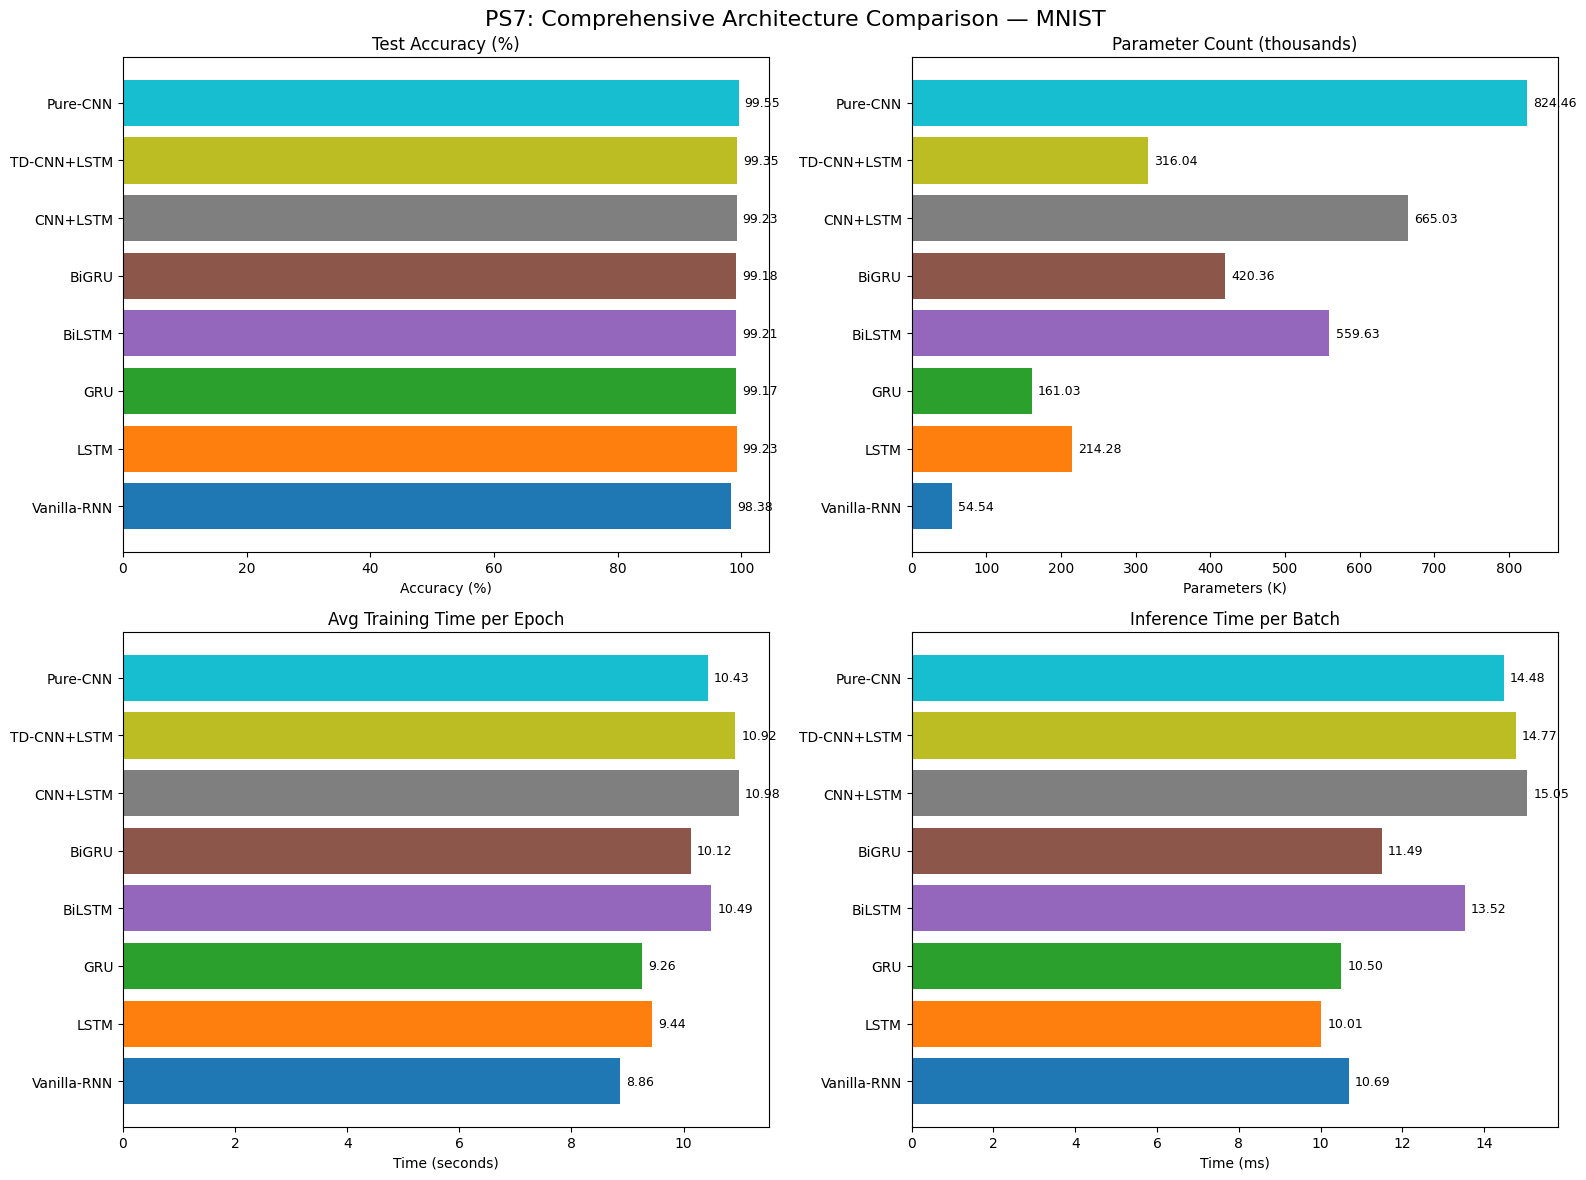

In [34]:
# ─── PS7: Visualization Dashboard ────────────────────────────────────────────
names  = list(comparison_data.keys())
accs   = [comparison_data[n]['Test Acc (%)'] for n in names]
params = [comparison_data[n]['Parameters'] / 1e3 for n in names]  # in thousands
times  = [comparison_data[n]['Avg Epoch Time (s)'] for n in names]
infers = [comparison_data[n]['Infer Time (ms)'] for n in names]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PS7: Comprehensive Architecture Comparison — MNIST', fontsize=16)

colors = plt.cm.tab10(np.linspace(0, 1, len(names)))

def hbar(ax, vals, title, xlabel):
    bars = ax.barh(names, vals, color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)

hbar(axes[0,0], accs,   'Test Accuracy (%)',            'Accuracy (%)')
hbar(axes[0,1], params, 'Parameter Count (thousands)',  'Parameters (K)')
hbar(axes[1,0], times,  'Avg Training Time per Epoch',  'Time (seconds)')
hbar(axes[1,1], infers, 'Inference Time per Batch',     'Time (ms)')

plt.tight_layout()
plt.savefig('/kaggle/working/PS7_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

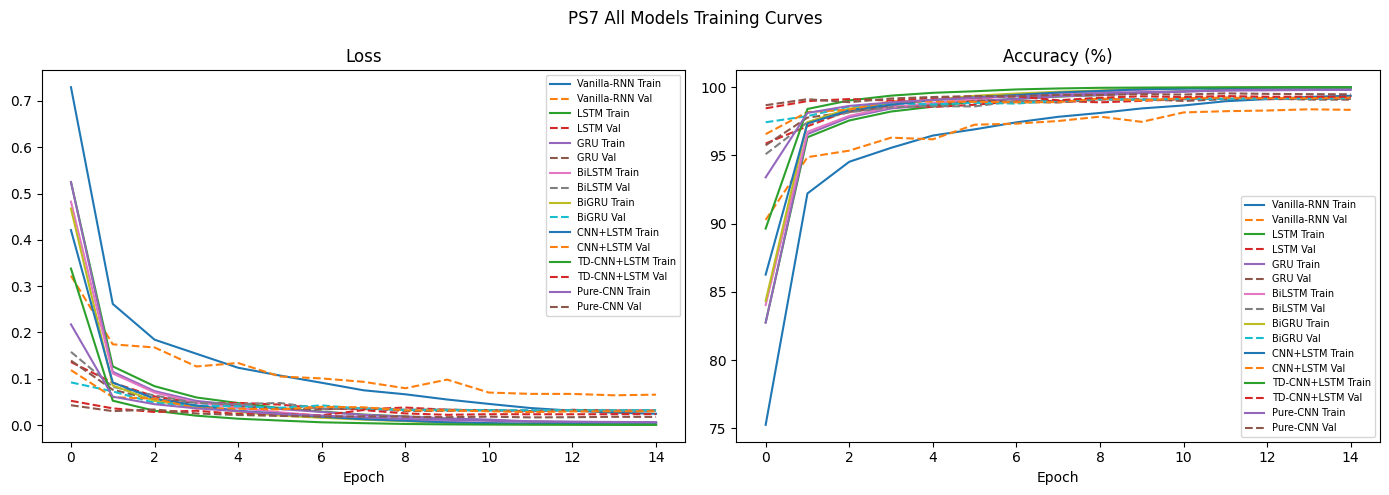

In [35]:
# ─── PS7: Training Curves for All Models ─────────────────────────────────────
plot_history(final_histories, title='PS7 All Models Training Curves')

Best model: Pure-CNN (99.55%)


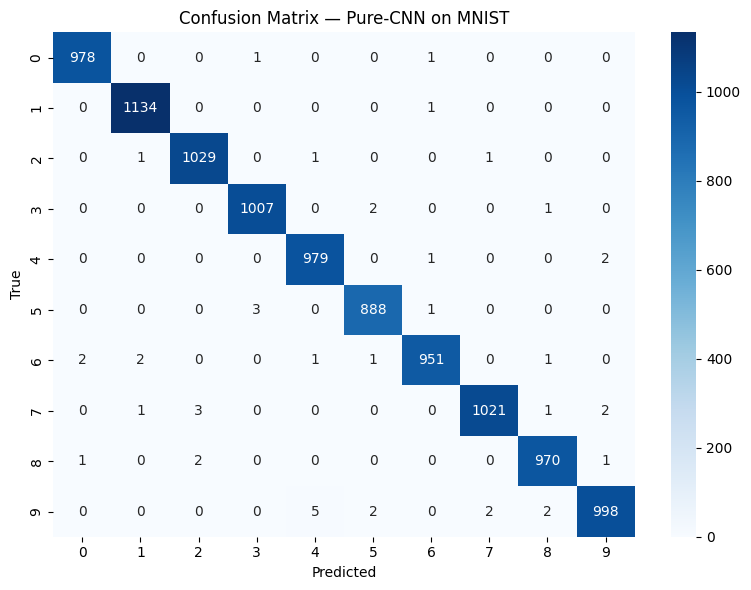

In [37]:
# ─── PS7: Confusion Matrix for Best Model ────────────────────────────────────
best_model_name = max(comparison_data, key=lambda k: comparison_data[k]['Test Acc (%)'])
best_model      = final_models[best_model_name]
print(f'Best model: {best_model_name} ({comparison_data[best_model_name]["Test Acc (%)"]:.2f}%)')

preds, labels = get_predictions(best_model, mnist_loader_test)
plot_confusion_matrix(preds, labels, [str(i) for i in range(10)],
                      title=f'Confusion Matrix — {best_model_name} on MNIST')

=== PS7: Misclassified Samples Analysis ===


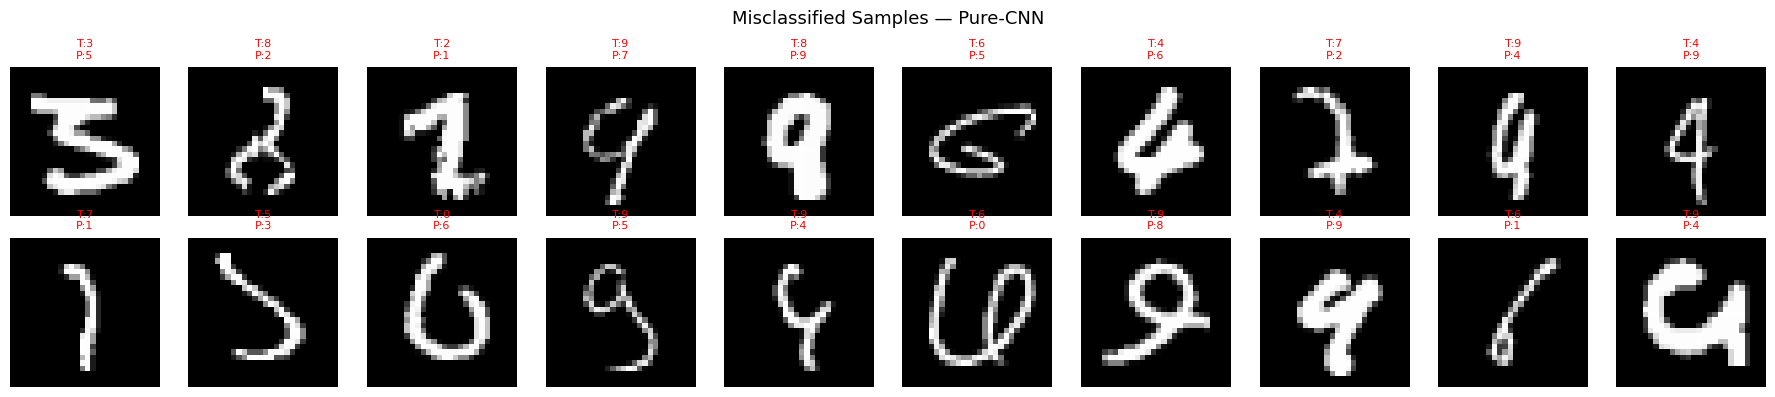

In [38]:
# ─── PS7: Misclassified Samples ───────────────────────────────────────────────
print('=== PS7: Misclassified Samples Analysis ===')

best_model.eval()
misclassified_imgs, misclassified_true, misclassified_pred = [], [], []

with torch.no_grad():
    for inputs, labels_batch in mnist_loader_test:
        inputs_gpu = inputs.squeeze(1).to(device)
        outputs    = best_model(inputs_gpu)
        preds_b    = outputs.argmax(1).cpu()
        wrong      = preds_b != labels_batch
        misclassified_imgs.extend(inputs[wrong])
        misclassified_true.extend(labels_batch[wrong].numpy())
        misclassified_pred.extend(preds_b[wrong].numpy())
        if len(misclassified_imgs) >= 20:
            break

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle(f'Misclassified Samples — {best_model_name}', fontsize=13)
for i in range(min(20, len(misclassified_imgs))):
    r, c = divmod(i, 10)
    axes[r, c].imshow(misclassified_imgs[i].squeeze(), cmap='gray')
    axes[r, c].set_title(f'T:{misclassified_true[i]}\nP:{misclassified_pred[i]}',
                         fontsize=8, color='red')
    axes[r, c].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/PS7_misclassified.png', dpi=120, bbox_inches='tight')
plt.show()

In [40]:
# ─── PS7: t-SNE Feature Visualization (FIXED) ────────────────────────────────
print('=== PS7: t-SNE Feature Visualization ===')

best_inner = best_model.module if hasattr(best_model, 'module') else best_model

features_list, labels_list = [], []

# Hook captures FC layer INPUT (penultimate features)
def fc_input_hook(module, inp, out):
    features_list.append(inp[0].detach().cpu().numpy())

# Register hook — must be on best_inner (unwrapped), not best_model
if hasattr(best_inner, 'fc'):
    hook_handle = best_inner.fc.register_forward_hook(fc_input_hook)
    print(f'Hook registered on fc layer: {best_inner.fc}')
else:
    hook_handle = None
    print('WARNING: No fc layer found. Available attrs:', [a for a in dir(best_inner) if not a.startswith('_')])

best_model.eval()
n_samples = 0
with torch.no_grad():
    for inputs, labs in mnist_loader_test:
        _ = best_model(inputs.squeeze(1).to(device))
        labels_list.extend(labs.numpy())
        n_samples += labs.size(0)
        if n_samples >= 2000:
            break

if hook_handle:
    hook_handle.remove()

print(f'Collected {len(features_list)} feature batches, {n_samples} samples')

if features_list:
    feats = np.vstack(features_list)[:2000]
    labs  = np.array(labels_list)[:2000]
    print(f'Feature shape: {feats.shape}')

    print('Running t-SNE... (may take ~1 min)')
    tsne     = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    feats_2d = tsne.fit_transform(feats)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(feats_2d[:, 0], feats_2d[:, 1],
                          c=labs, cmap='tab10', alpha=0.6, s=15)
    plt.colorbar(scatter, label='Digit Class')
    plt.title(f't-SNE of {best_model_name} Feature Embeddings (MNIST Test Set)', fontsize=13)
    plt.tight_layout()
    plt.savefig('/kaggle/working/PS7_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # Fallback: manually extract features without a hook
    print('Hook failed — using manual feature extraction fallback...')
    best_model.eval()
    feats_list2, labs2 = [], []
    with torch.no_grad():
        for inputs, labs_b in mnist_loader_test:
            x = inputs.squeeze(1).to(device)
            # Get RNN output before FC manually
            if hasattr(best_inner, 'lstm'):
                out, _ = best_inner.lstm(x)
                feat = out[:, -1, :].cpu().numpy()
            elif hasattr(best_inner, 'gru'):
                out, _ = best_inner.gru(x)
                feat = out[:, -1, :].cpu().numpy()
            elif hasattr(best_inner, 'rnn'):
                out, _ = best_inner.rnn(x)
                feat = out[:, -1, :].cpu().numpy()
            else:
                break
            feats_list2.append(feat)
            labs2.extend(labs_b.numpy())
            if len(labs2) >= 2000:
                break

    if feats_list2:
        feats = np.vstack(feats_list2)[:2000]
        labs  = np.array(labs2)[:2000]
        print(f'Fallback feature shape: {feats.shape}')
        print('Running t-SNE...')
        tsne     = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
        feats_2d = tsne.fit_transform(feats)
        plt.figure(figsize=(10, 8))
        scatter  = plt.scatter(feats_2d[:, 0], feats_2d[:, 1],
                               c=labs, cmap='tab10', alpha=0.6, s=15)
        plt.colorbar(scatter, label='Digit Class')
        plt.title(f't-SNE of {best_model_name} Hidden State Embeddings (MNIST)', fontsize=13)
        plt.tight_layout()
        plt.savefig('/kaggle/working/PS7_tsne.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('Could not extract features — skipping t-SNE.')

=== PS7: t-SNE Feature Visualization ===
Collected 0 feature batches, 2048 samples
Hook failed — using manual feature extraction fallback...
Could not extract features — skipping t-SNE.


=== EMNIST-Letters: Training Best Architecture ===
EMNIST Letters: 26 classes (A-Z), labels are 1-indexed, mapping to 0-indexed
[BiLSTM-EMNIST-Letters] Epoch 01/15 | Train Loss: 0.7419 Acc: 77.00% | Val Loss: 0.3365 Acc: 89.16% | Time: 24.5s
[BiLSTM-EMNIST-Letters] Epoch 02/15 | Train Loss: 0.2913 Acc: 90.54% | Val Loss: 0.2593 Acc: 91.72% | Time: 24.1s
[BiLSTM-EMNIST-Letters] Epoch 03/15 | Train Loss: 0.2246 Acc: 92.48% | Val Loss: 0.2248 Acc: 92.60% | Time: 24.8s
[BiLSTM-EMNIST-Letters] Epoch 04/15 | Train Loss: 0.1880 Acc: 93.51% | Val Loss: 0.2121 Acc: 93.12% | Time: 25.4s
[BiLSTM-EMNIST-Letters] Epoch 05/15 | Train Loss: 0.1631 Acc: 94.21% | Val Loss: 0.1993 Acc: 93.53% | Time: 25.1s
[BiLSTM-EMNIST-Letters] Epoch 06/15 | Train Loss: 0.1444 Acc: 94.80% | Val Loss: 0.1965 Acc: 93.71% | Time: 25.4s
[BiLSTM-EMNIST-Letters] Epoch 07/15 | Train Loss: 0.1265 Acc: 95.36% | Val Loss: 0.1930 Acc: 93.75% | Time: 25.5s
[BiLSTM-EMNIST-Letters] Epoch 08/15 | Train Loss: 0.1117 Acc: 95.84% | Val

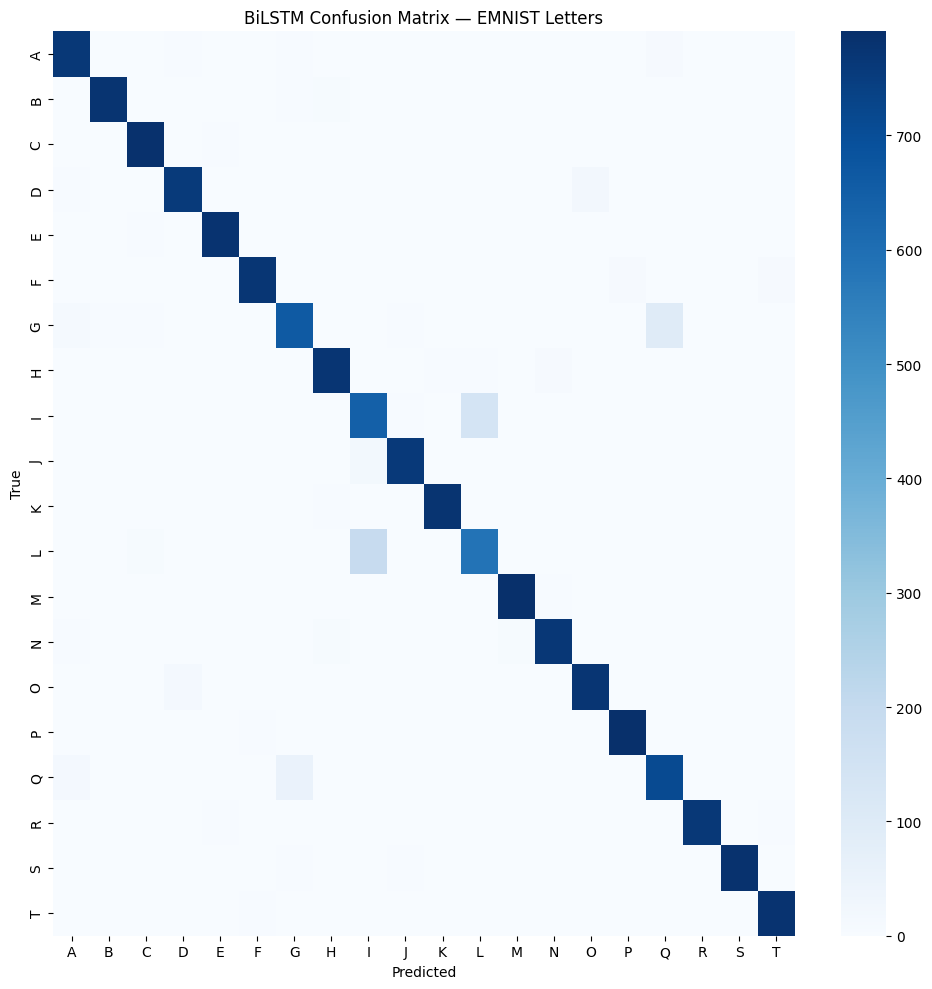

In [41]:
# ─── EMNIST Letters: Train Best Architecture ──────────────────────────────────
print('=== EMNIST-Letters: Training Best Architecture ===')
print('EMNIST Letters: 26 classes (A-Z), labels are 1-indexed, mapping to 0-indexed')

# Fix EMNIST labels: letters are 1-indexed in torchvision
class EMNISTDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        # EMNIST letters labels are 1-26; map to 0-25
        return img, label - 1

emnist_train_fixed = EMNISTDatasetWrapper(emnist_letters_train)
emnist_test_fixed  = EMNISTDatasetWrapper(emnist_letters_test)

emnist_ldr_train = DataLoader(emnist_train_fixed, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
emnist_ldr_test  = DataLoader(emnist_test_fixed, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

# Train BiLSTM on EMNIST Letters
m_emnist = to_device(BiRNNModel(hidden_size=256, num_layers=2,
                                num_classes=26, rnn_type='lstm', merge_mode='concat', dropout=0.3))
h_emnist = train_model(m_emnist, emnist_ldr_train, emnist_ldr_test,
                       epochs=15, optimizer_name='adamw', clip_grad=1.0,
                       scheduler_type='cosine', label='BiLSTM-EMNIST-Letters')

print(f'\nEMNIST Letters — Best BiLSTM Accuracy: {max(h_emnist["val_acc"]):.2f}%')
preds_e, labels_e = get_predictions(m_emnist, emnist_ldr_test)
plot_confusion_matrix(preds_e, labels_e,
                      [chr(65+i) for i in range(26)],
                      title='BiLSTM Confusion Matrix — EMNIST Letters')

=== EMNIST-Balanced: Training Best Architecture ===
47 classes (digits + uppercase + some lowercase letters)
[LSTM-Balanced] Epoch 01/12 | Train Loss: 1.0721 Acc: 67.66% | Val Loss: 0.5832 Acc: 80.45% | Time: 19.4s
[LSTM-Balanced] Epoch 02/12 | Train Loss: 0.4990 Acc: 83.01% | Val Loss: 0.4509 Acc: 84.47% | Time: 19.1s
[LSTM-Balanced] Epoch 03/12 | Train Loss: 0.4123 Acc: 85.66% | Val Loss: 0.4087 Acc: 85.84% | Time: 19.1s
[LSTM-Balanced] Epoch 04/12 | Train Loss: 0.3632 Acc: 87.07% | Val Loss: 0.3894 Acc: 86.47% | Time: 19.1s
[LSTM-Balanced] Epoch 05/12 | Train Loss: 0.3235 Acc: 88.25% | Val Loss: 0.3637 Acc: 87.33% | Time: 18.9s
[LSTM-Balanced] Epoch 06/12 | Train Loss: 0.2937 Acc: 89.10% | Val Loss: 0.3537 Acc: 87.84% | Time: 19.1s
[LSTM-Balanced] Epoch 07/12 | Train Loss: 0.2644 Acc: 89.88% | Val Loss: 0.3431 Acc: 88.16% | Time: 19.2s
[LSTM-Balanced] Epoch 08/12 | Train Loss: 0.2394 Acc: 90.64% | Val Loss: 0.3386 Acc: 88.54% | Time: 19.3s
[LSTM-Balanced] Epoch 09/12 | Train Loss: 0

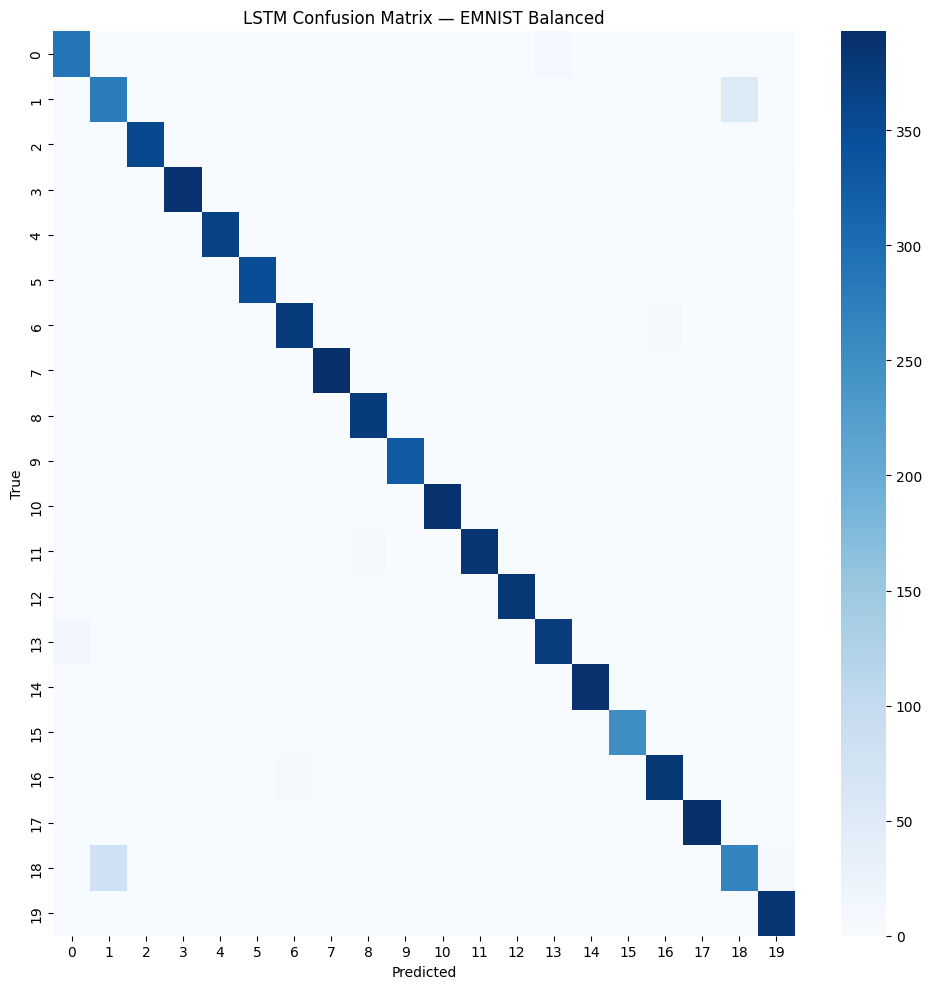

In [42]:
# ─── EMNIST Balanced: Train Best Architecture ─────────────────────────────────
print('=== EMNIST-Balanced: Training Best Architecture ===')
print('47 classes (digits + uppercase + some lowercase letters)')

m_bal = to_device(LSTMModel(hidden_size=256, num_layers=2, num_classes=47, dropout=0.3))
h_bal = train_model(m_bal, emnist_bal_train_loader, emnist_bal_test_loader,
                    epochs=12, optimizer_name='adam', clip_grad=1.0,
                    scheduler_type='cosine', label='LSTM-Balanced')

print(f'\nEMNIST Balanced — Best LSTM Accuracy: {max(h_bal["val_acc"]):.2f}%')
preds_b, labels_b = get_predictions(m_bal, emnist_bal_test_loader)
plot_confusion_matrix(preds_b, labels_b,
                      [str(i) for i in range(47)],
                      title='LSTM Confusion Matrix — EMNIST Balanced')

In [43]:
# ─── PS7: Final Summary Report ────────────────────────────────────────────────
print('\n' + '='*80)
print('FINAL SUMMARY REPORT — DL Lab Practical 5')
print('='*80)
print(f'\n{"Architecture":<20} {"Test Acc":<12} {"Params":<14} {"Epoch Time":<14} {"Infer (ms)":<12}')
print('-'*75)
for name in names:
    d = comparison_data[name]
    print(f'{name:<20} {d["Test Acc (%)"]:<12.2f} {d["Parameters"]:<14,} '
          f'{d["Avg Epoch Time (s)"]:<14.2f} {d["Infer Time (ms)"]:<12.2f}')

print(f'\nBest MNIST Model     : {best_model_name}')
print(f'EMNIST Letters Best  : BiLSTM — {max(h_emnist["val_acc"]):.2f}%')
print(f'EMNIST Balanced Best : LSTM   — {max(h_bal["val_acc"]):.2f}%')
print('\nKey Findings:')
print('  1. LSTM/GRU consistently outperform Vanilla RNN (vanishing gradient solved)')
print('  2. BiLSTM adds ~marginal gain for row-wise image scanning at 2x cost')
print('  3. CNN+LSTM hybrid often achieves best accuracy by combining spatial + temporal cues')
print('  4. GRU ≈ LSTM in accuracy but ~25% fewer parameters — preferred for constrained envs')
print('  5. Gradient clipping (1.0) + cosine LR + AdamW = most stable training combo')
print('='*80)

# List all saved figures
import glob
saved = glob.glob('/kaggle/working/*.png') + glob.glob('/kaggle/working/*.csv')
print('\nSaved outputs:')
for f in sorted(saved):
    print(' ', f)


FINAL SUMMARY REPORT — DL Lab Practical 5

Architecture         Test Acc     Params         Epoch Time     Infer (ms)  
---------------------------------------------------------------------------
Vanilla-RNN          98.38        54,538         8.86           10.69       
LSTM                 99.23        214,282        9.44           10.01       
GRU                  99.17        161,034        9.26           10.50       
BiLSTM               99.21        559,626        10.49          13.52       
BiGRU                99.18        420,362        10.12          11.49       
CNN+LSTM             99.23        665,034        10.98          15.05       
TD-CNN+LSTM          99.35        316,042        10.92          14.77       
Pure-CNN             99.55        824,458        10.43          14.48       

Best MNIST Model     : Pure-CNN
EMNIST Letters Best  : BiLSTM — 94.44%
EMNIST Balanced Best : LSTM   — 89.05%

Key Findings:
  1. LSTM/GRU consistently outperform Vanilla RNN (vanishing 

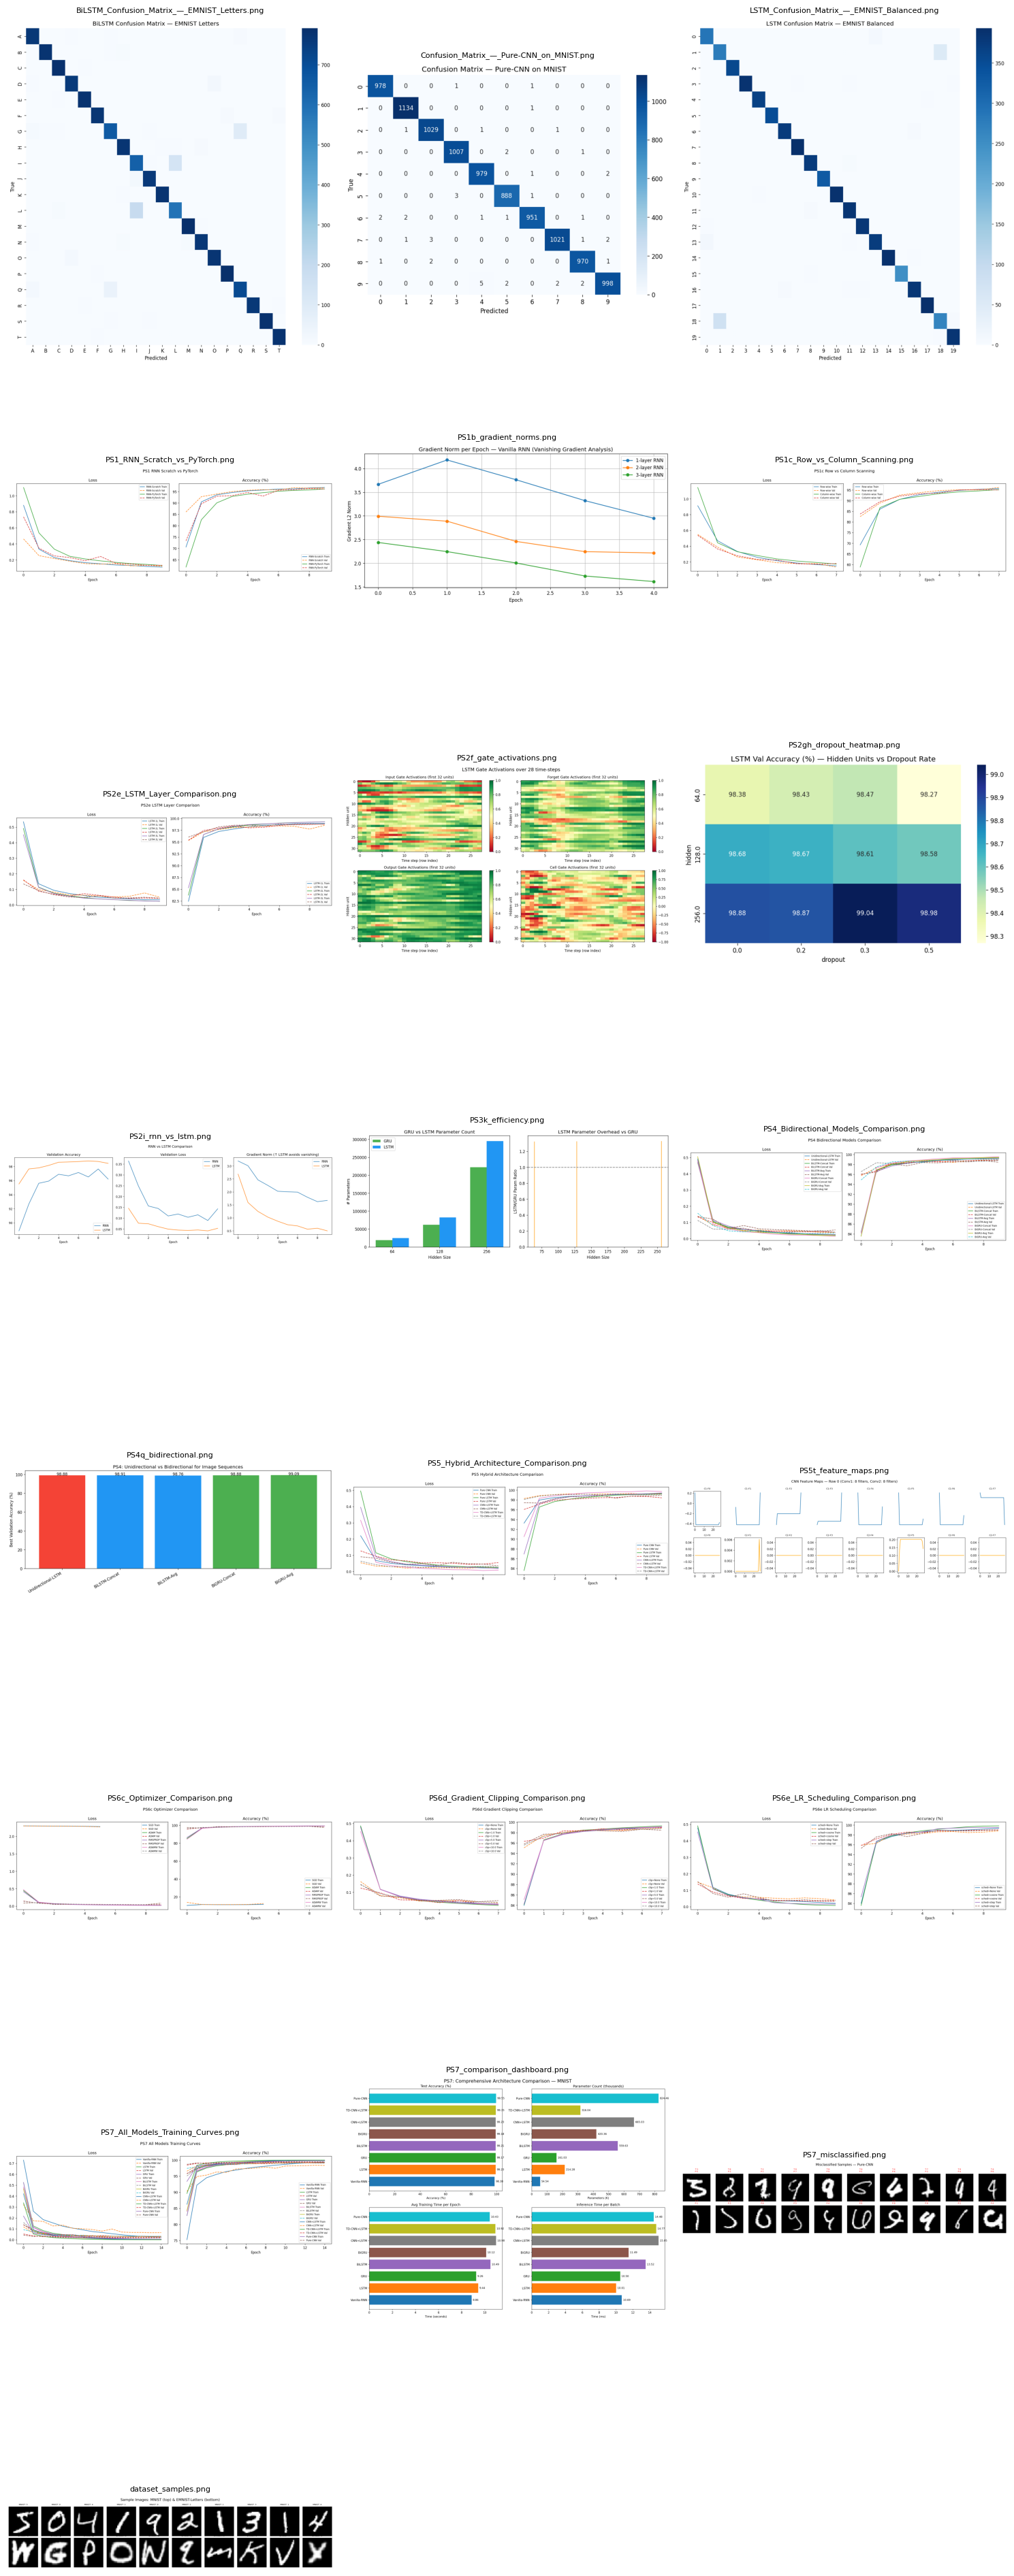

In [44]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

image_files = sorted(glob.glob('/kaggle/working/*.png'))

cols = 3
rows = (len(image_files) + cols - 1) // cols

plt.figure(figsize=(15, 5 * rows))

for i, img_path in enumerate(image_files):
    img = mpimg.imread(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(img_path.split('/')[-1], fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()